In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import shap

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, cross_val_predict, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (ConstantKernel, RBF, WhiteKernel)
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor

from scipy.stats import spearmanr

## Data Setup

In [2]:
# target variables: 'proctor_mdd_g_cm3', 'proctor_owc_pct'
df = pd.read_csv('./data/train.csv')
features_o = df.columns.drop(['id', 'proctor_mdd_g_cm3', 'proctor_owc_pct'])

df['clay'] = df['psd_passing_at_0_002mm_pct']
df['silt'] = df['psd_passing_at_0_063mm_pct'] - df['psd_passing_at_0_002mm_pct']
df['sand'] = df['psd_passing_at_2mm_pct'] - df['psd_passing_at_0_063mm_pct']
df['gravel'] = 100 - df['psd_passing_at_2mm_pct']
df['fine-grained'] = (df['clay'] + df['silt'] > 12)

# Geotechnical gradation indices
df['feat_cu'] = df['psd_size_at_d60_mm'].replace(0, np.nan) / df['psd_size_at_d10_mm'].replace(0, np.nan) # Coefficient of uniformity
df['feat_cc'] = (df['psd_size_at_d30_mm'] ** 2) / (df['psd_size_at_d60_mm'].replace(0, np.nan) * df['psd_size_at_d10_mm'].replace(0, np.nan)) # Coefficient of curvature
df['feat_log_cu'] = np.log1p(df['feat_cu']) # Log-CU (skewed distribution)
df['feat_pi'] = df['atterberg_liquid_limit_pct'] - df['atterberg_plastic_limit_pct'] # Plasticity Index


features = df.columns.drop(['id', 'proctor_mdd_g_cm3', 'proctor_owc_pct'])

In [3]:
targets = ['proctor_mdd_g_cm3', 'proctor_owc_pct']

## Correlation

### Pearson Correlation

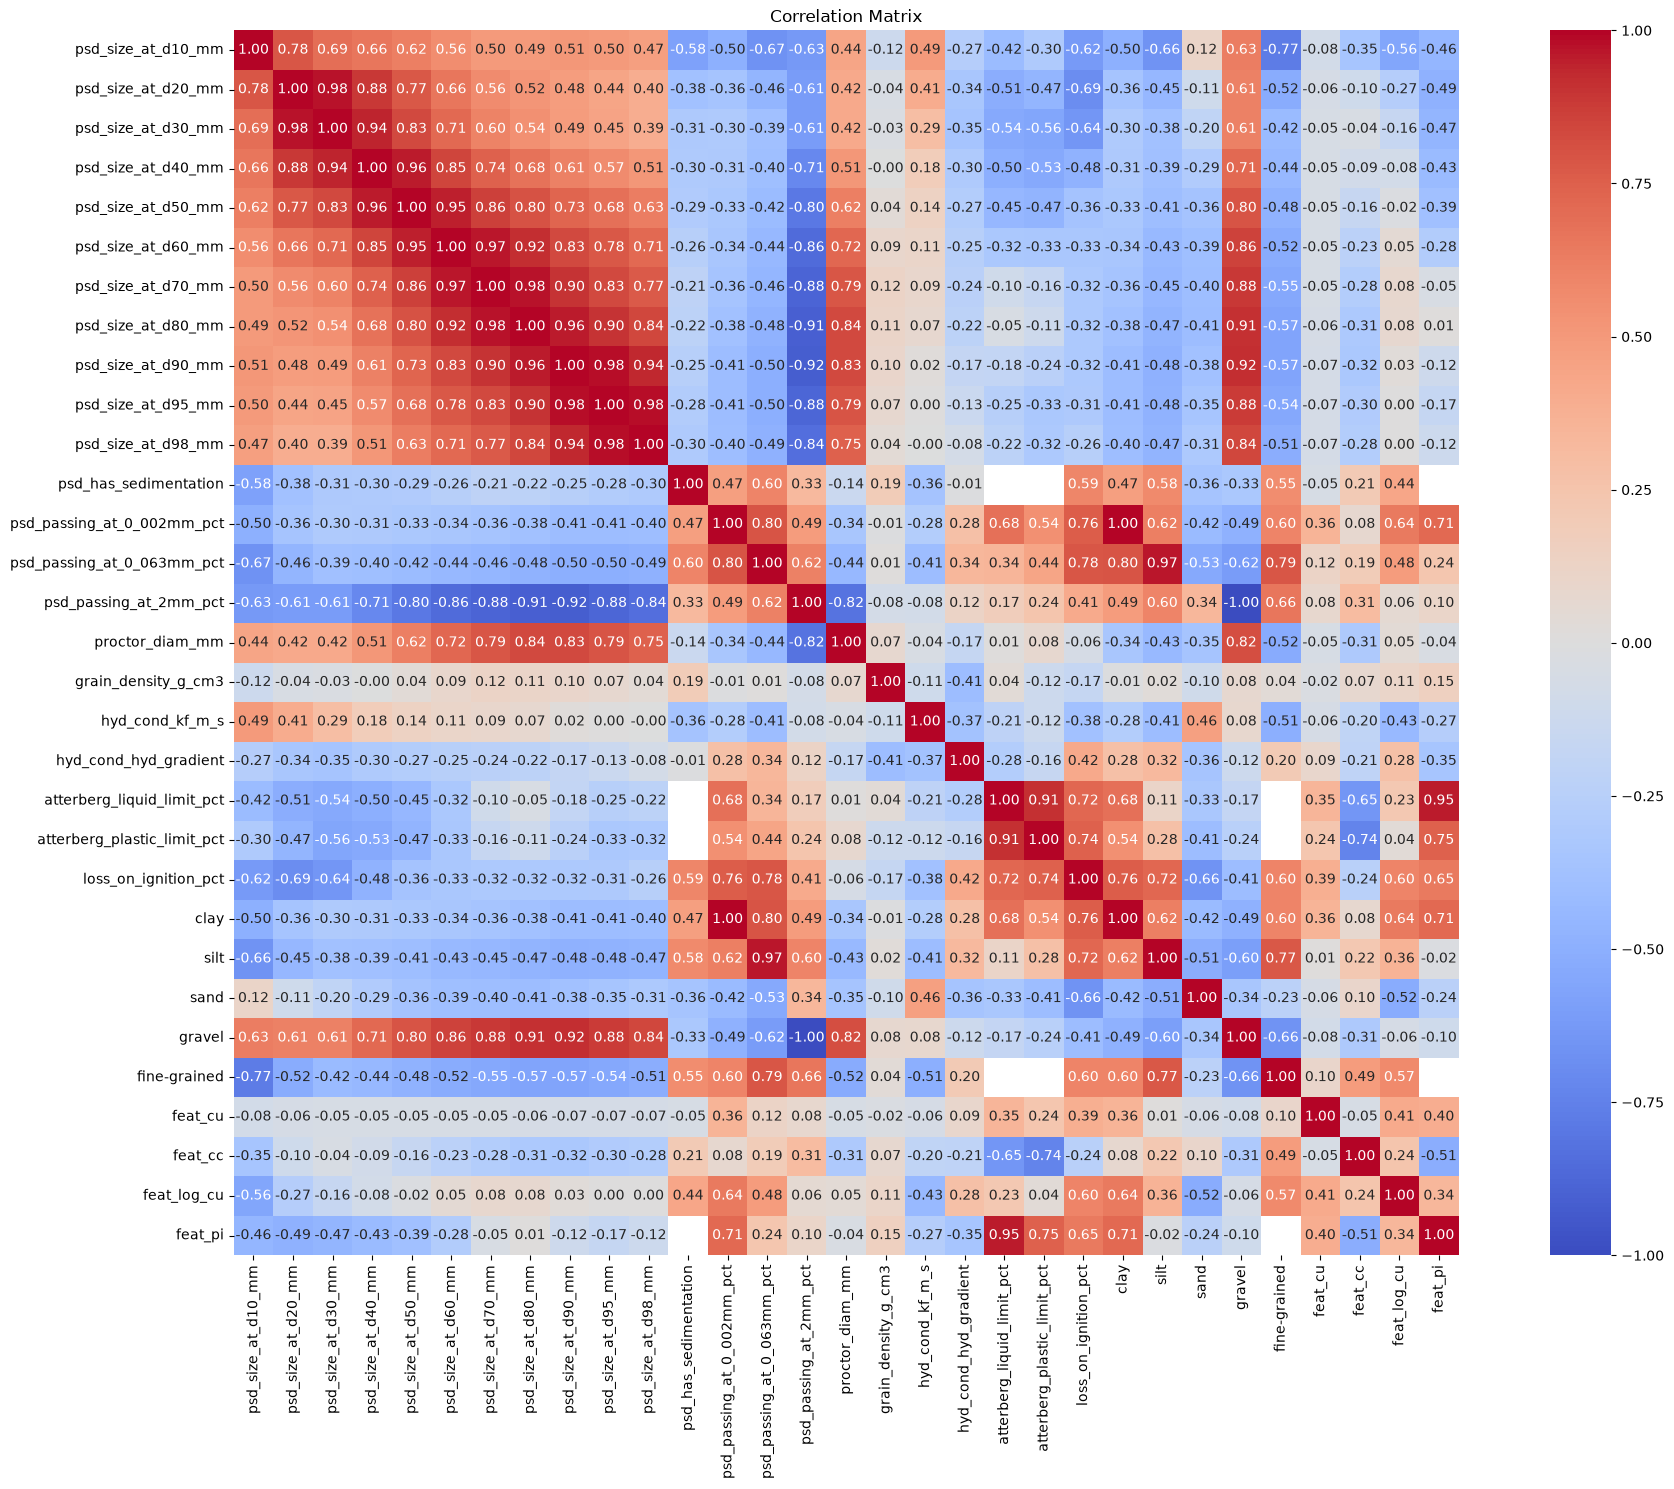

In [4]:
corr_mat = df[features].corr().round(5)

plt.figure(figsize=(20, 15))

sns.heatmap(
    corr_mat,
    cmap='coolwarm',
    annot=True,      # Show correlation values
    fmt='.2f',       # 2 decimal places
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [5]:
# Checking for correlation value greater than 0.6

temp = ['psd_has_sedimentation', 'psd_passing_at_0_002mm_pct', 'psd_passing_at_0_063mm_pct',
       'psd_passing_at_2mm_pct', 'proctor_diam_mm', 'grain_density_g_cm3', 'hyd_cond_kf_m_s',
       'hyd_cond_hyd_gradient', 'atterberg_liquid_limit_pct', 'atterberg_plastic_limit_pct', 'loss_on_ignition_pct']

lst = []

for col in df[temp]:
    for row in df[temp]:
        if row == col:  # want upper trianglar
            break
        elif abs(corr_mat.loc[row, col]) >= 0.9:
            lst.append([row, col])

# len(lst)
lst

[['atterberg_liquid_limit_pct', 'atterberg_plastic_limit_pct']]

In [6]:
# Pearson Correlation - how strongly two variables have a linear relationship

# Features and targets
X = df[features]
y_mdd = df["proctor_mdd_g_cm3"]
y_owc = df["proctor_owc_pct"]

# Compute correlations
pearson_mdd = X.corrwith(y_mdd, method="pearson")
pearson_owc = X.corrwith(y_owc, method="pearson")

# Combine into one DataFrame
pearson_df = pd.DataFrame({
    "MDD_pearson": pearson_mdd,
    "OWC_pearson": pearson_owc
})

### Spearman Correlation

In [7]:
# Features and targets
X = df[features]
y_mdd = df["proctor_mdd_g_cm3"]
y_owc = df["proctor_owc_pct"]

# Compute correlations
spearman_mdd = X.corrwith(y_mdd, method="spearman")
spearman_owc = X.corrwith(y_owc, method="spearman")

# Combine into one DataFrame
spearman_df = pd.DataFrame({
    "MDD_spearman": spearman_mdd,
    "OWC_spearman": spearman_owc
})

### Pairwise Correlation

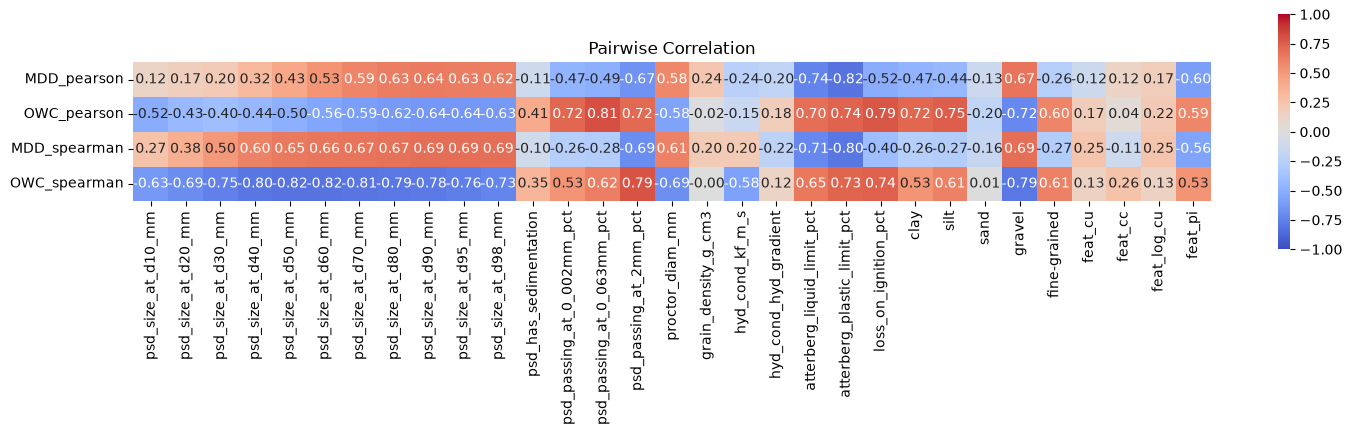

In [8]:
corr_pairwise_mat = pd.concat([pearson_df, spearman_df], axis=1)

plt.figure(figsize=(15,4))

sns.heatmap(
    corr_pairwise_mat.T,
    cmap='coolwarm',
    annot=True,      # Show correlation values
    fmt='.2f',       # 2 decimal places
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Pairwise Correlation")
plt.tight_layout()
plt.show()

### Mutual Information

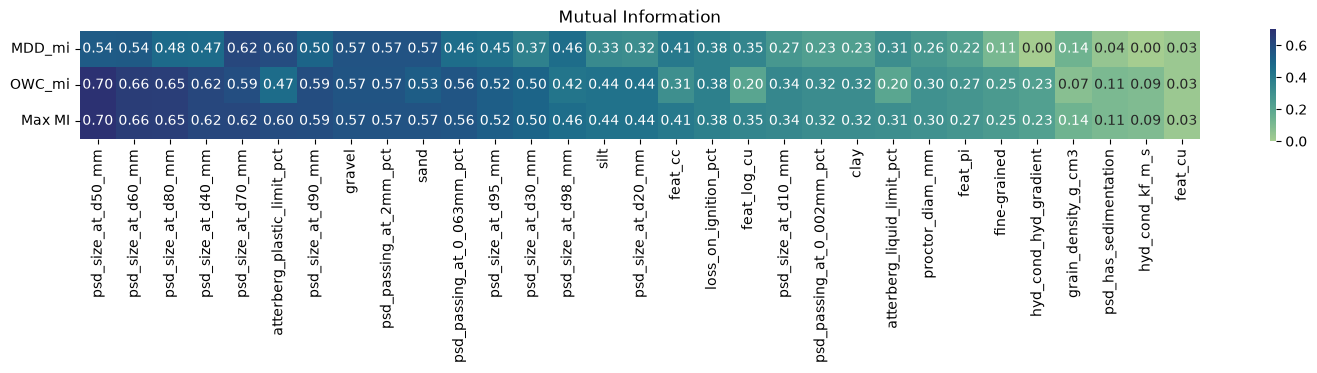

In [9]:
# Mutual Information - how much knowing one variable reduces your uncertainty about another variable

mi_mdd = {}
mi_owc = {}

for feature in X.columns:
    # ----- MDD -----
    temp = pd.concat([X[feature], y_mdd], axis=1).dropna()

    mi_mdd[feature] = mutual_info_regression(
        temp[[feature]],
        temp[y_mdd.name],
        random_state=42
    )[0]

    # ----- OWC -----
    temp = pd.concat([X[feature], y_owc], axis=1).dropna()

    mi_owc[feature] = mutual_info_regression(
        temp[[feature]],
        temp[y_owc.name],
        random_state=42
    )[0]

mi_df = pd.DataFrame({
    "MDD_mi": mi_mdd,
    "OWC_mi": mi_owc
})

mi_df["Max MI"] = mi_df.max(axis=1)
mi_df = mi_df.sort_values("Max MI", ascending=False)

plt.figure(figsize=(15, 3))
sns.heatmap(
    mi_df.T,
    cmap='crest',
    annot=True,      # Show correlation values
    fmt='.2f',       # 2 decimal places
    vmin=0,
    square=True,
)

plt.title("Mutual Information")
plt.tight_layout()
plt.show()

## Linearity

In [10]:
params_av = df.columns.drop(['hyd_cond_kf_m_s', 'hyd_cond_hyd_gradient', 'atterberg_liquid_limit_pct', 
                             'atterberg_plastic_limit_pct', 'loss_on_ignition_pct', 'feat_pi', 'id', 'proctor_mdd_g_cm3', 'proctor_owc_pct'])

df_reg = df.copy()

### Linear Regression

In [11]:
# How much of the problem is linearly explainable
# Which features still matter after accounting for all the others

X = df[params_av]
y1 = df[targets[0]]   # MDD
y2 = df[targets[1]]   # OWC

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model1 = make_pipeline(StandardScaler(), LinearRegression())
model2 = make_pipeline(StandardScaler(), LinearRegression())

cv_mdd = cross_validate(
    model1,
    X,
    y1,
    cv=cv,
    scoring="r2",
    return_train_score=True
)

cv_owc = cross_validate(
    model2,
    X,
    y2,
    cv=cv,
    scoring="r2",
    return_train_score=True
)

cv_results_lin = pd.DataFrame({
    "MDD train R2": cv_mdd["train_score"],
    "MDD validation R2": cv_mdd["test_score"],
    "OWC train R2": cv_owc["train_score"],
    "OWC validation R2": cv_owc["test_score"]
})

cv_results_lin.index = [f"Fold {i}" for i in range(1, len(cv_results_lin) + 1)]

cv_results_lin.loc["Mean"] = cv_results_lin.mean()
cv_results_lin.loc["Std"] = cv_results_lin.std()

cv_results_lin

,MDD train R2,MDD validation R2,OWC train R2,OWC validation R2
Fold 1,0.836696,0.630188,0.853102,0.613692
Fold 2,0.824884,0.674293,0.826146,0.769505
Fold 3,0.812550,0.755529,0.827822,0.764309
Fold 4,0.786667,0.854315,0.807393,-1.450724
Fold 5,0.804525,0.805894,0.818225,0.812402
Mean,0.813064,0.744044,0.826538,0.301837
Std,0.017136,0.082396,0.015120,0.878862


In [12]:
# If this feature increases by one unit, while all other features stay fixed, how much does the predicted target change?

model1.fit(X, y1)
model2.fit(X, y2)

coef1 = pd.Series(model1.named_steps["linearregression"].coef_, index=X.columns)
coef2 = pd.Series(model2.named_steps["linearregression"].coef_, index=X.columns)

a = coef1.sort_values()
b = coef2.sort_values()

pd.concat([a, b], axis=1).rename(columns={0 : 'mdd', 1 : 'owc'})

,mdd,owc
psd_size_at_d60_mm,-0.088817,1.831689
psd_size_at_d90_mm,-0.047083,-0.395053
psd_passing_at_2mm_pct,-0.044179,0.428198
psd_size_at_d30_mm,-0.042143,-2.847412
psd_size_at_d10_mm,-0.036999,-0.874500
psd_passing_at_0_063mm_pct,-0.027203,0.594263
silt,-0.025780,0.463975
psd_size_at_d80_mm,-0.024318,2.053701
psd_passing_at_0_002mm_pct,-0.023015,0.744576
clay,-0.023015,0.744576


In [13]:
mdd_oof_pred = cross_val_predict(model1, X, y1, cv=cv)
owc_oof_pred = cross_val_predict(model2, X, y2, cv=cv)

In [14]:
# Linear Predictions & Residuals
df_reg['mdd_lin_pred'] = mdd_oof_pred
df_reg['owc_lin_pred'] = owc_oof_pred
df_reg['mdd_lin_res'] = df_reg['proctor_mdd_g_cm3'] - df_reg['mdd_lin_pred']
df_reg['owc_lin_res'] = df_reg['proctor_owc_pct'] - df_reg['owc_lin_pred']
df_reg['mdd_lin_res_pct'] = (df_reg['proctor_mdd_g_cm3'] - df_reg['mdd_lin_pred']) / df_reg['proctor_mdd_g_cm3']
df_reg['owc_lin_res_pct'] = (df_reg['proctor_owc_pct'] - df_reg['owc_lin_pred']) / df_reg['proctor_owc_pct']
df_reg

,id,psd_size_at_d10_mm,psd_size_at_d20_mm,psd_size_at_d30_mm,psd_size_at_d40_mm,psd_size_at_d50_mm,psd_size_at_d60_mm,psd_size_at_d70_mm,psd_size_at_d80_mm,psd_size_at_d90_mm,...,feat_cu,feat_cc,feat_log_cu,feat_pi,mdd_lin_pred,owc_lin_pred,mdd_lin_res,owc_lin_res,mdd_lin_res_pct,owc_lin_res_pct
0,0,0.136773,0.315214,0.547515,0.933930,1.788142,3.313938,7.214010,12.517275,20.160863,...,24.229475,0.661374,3.228013,NaN,2.099124,7.316685,-0.031124,0.743315,-0.015050,0.092223
1,1,0.014579,0.062060,0.119258,0.221877,0.423550,1.022249,2.978369,6.081199,10.622063,...,70.117909,0.954313,4.264339,NaN,2.092984,9.721143,-0.055984,0.698857,-0.027484,0.067069
2,2,0.003243,0.022301,0.087024,0.156595,0.217595,0.323793,0.512853,1.546115,10.921905,...,99.843663,7.212132,4.613571,12.70,2.098875,10.242048,-0.047875,0.697952,-0.023342,0.063798
3,3,0.000355,0.000859,0.002080,0.004772,0.009031,0.015228,0.025404,0.041920,0.151357,...,42.895775,0.800305,3.781818,25.19,1.666542,19.638413,-0.018542,0.671587,-0.011251,0.033067
4,4,0.000360,0.004868,0.010546,0.015848,0.021282,0.026753,0.033510,0.042328,0.067946,...,74.313889,11.547834,4.321665,NaN,1.904840,15.605387,-0.084840,0.154613,-0.046616,0.009810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,196,0.100777,0.212256,0.341667,0.526610,0.955715,2.339938,4.493148,7.795487,16.941993,...,23.218969,0.495040,3.187136,NaN,2.088715,7.425472,-0.031715,0.474528,-0.015418,0.060067
197,197,0.090191,0.126268,0.176777,0.247489,0.346487,0.485085,0.679124,0.950781,1.847298,...,5.378419,0.714283,1.852920,NaN,1.892141,10.363236,-0.042141,-2.163236,-0.022779,-0.263809
198,198,0.176777,0.303513,0.407383,0.559104,0.807431,1.353154,3.230437,9.337932,19.882790,...,7.654582,0.693798,2.158089,NaN,1.993975,8.629379,0.065025,0.390621,0.031581,0.043306
199,199,0.000390,0.001069,0.002937,0.007530,0.014572,0.031049,0.105558,0.312777,0.629716,...,79.612821,0.712354,4.389658,NaN,1.741073,17.283858,-0.030073,1.746142,-0.017576,0.091757


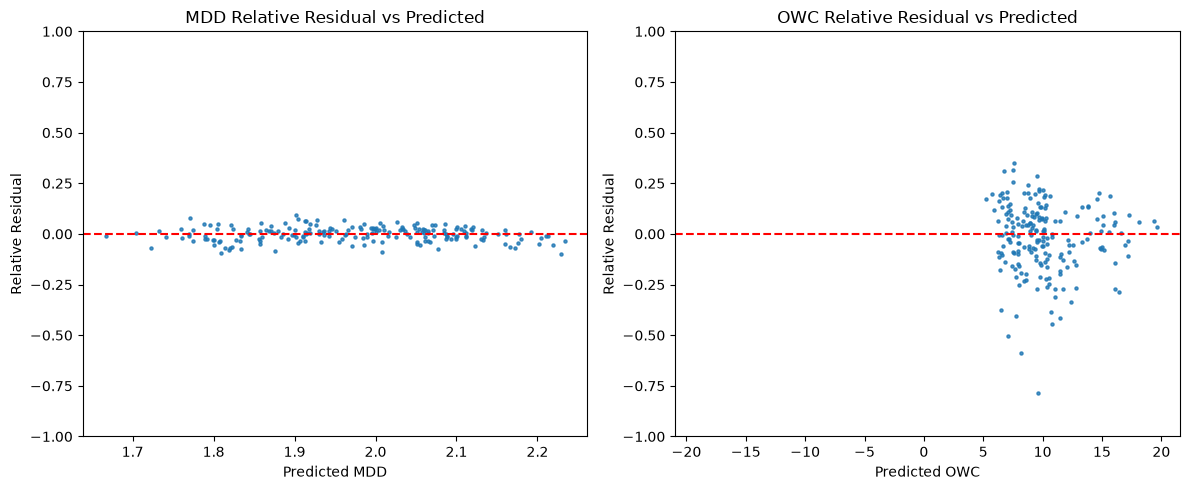

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].set_ylim(-1, 1)
ax[1].set_ylim(-1, 1)

# MDD
ax[0].scatter(
    df_reg['mdd_lin_pred'],
    df_reg['mdd_lin_res_pct'],
    alpha=0.8,
    s=5
)
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_xlabel("Predicted MDD")
ax[0].set_ylabel("Relative Residual")
ax[0].set_title("MDD Relative Residual vs Predicted")

# OWC
ax[1].scatter(
    df_reg['owc_lin_pred'],
    df_reg['owc_lin_res_pct'],
    alpha=0.8,
    s=5
)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_xlabel("Predicted OWC")
ax[1].set_ylabel("Relative Residual")
ax[1].set_title("OWC Relative Residual vs Predicted")

plt.tight_layout()
plt.show()

### Ridge

In [16]:
# Linear Predictions & Residuals with Ridge

alphas = np.logspace(-4, 4, 100)

model3 = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=5))
model4 = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=5))

model3.fit(X, y1)
model4.fit(X, y2)

mdd_oof_pred = cross_val_predict(model3, X, y1, cv=cv)
owc_oof_pred = cross_val_predict(model4, X, y2, cv=cv)

df_reg['mdd_ridge'] = mdd_oof_pred
df_reg['owc_ridge'] = owc_oof_pred
df_reg['mdd_ridge_res'] = df_reg['proctor_mdd_g_cm3'] - df_reg['mdd_ridge']
df_reg['owc_ridge_res'] = df_reg['proctor_owc_pct'] - df_reg['owc_ridge']
df_reg['mdd_ridge_res_pct'] = (df_reg['proctor_mdd_g_cm3'] - df_reg['mdd_ridge']) / df_reg['proctor_mdd_g_cm3']
df_reg['owc_ridge_res_pct'] = (df_reg['proctor_owc_pct'] - df_reg['owc_ridge']) / df_reg['proctor_owc_pct']

print("Best alpha (MDD):", model3.named_steps["ridgecv"].alpha_)
print("Best alpha (OWC):", model4.named_steps["ridgecv"].alpha_)

df_reg

Best alpha (MDD): 17.886495290574352
Best alpha (OWC): 25.950242113997373


,id,psd_size_at_d10_mm,psd_size_at_d20_mm,psd_size_at_d30_mm,psd_size_at_d40_mm,psd_size_at_d50_mm,psd_size_at_d60_mm,psd_size_at_d70_mm,psd_size_at_d80_mm,psd_size_at_d90_mm,...,mdd_lin_res,owc_lin_res,mdd_lin_res_pct,owc_lin_res_pct,mdd_ridge,owc_ridge,mdd_ridge_res,owc_ridge_res,mdd_ridge_res_pct,owc_ridge_res_pct
0,0,0.136773,0.315214,0.547515,0.933930,1.788142,3.313938,7.214010,12.517275,20.160863,...,-0.031124,0.743315,-0.015050,0.092223,2.084984,7.470042,-0.016984,0.589958,-0.008213,0.073196
1,1,0.014579,0.062060,0.119258,0.221877,0.423550,1.022249,2.978369,6.081199,10.622063,...,-0.055984,0.698857,-0.027484,0.067069,2.068569,9.971334,-0.031569,0.448666,-0.015498,0.043058
2,2,0.003243,0.022301,0.087024,0.156595,0.217595,0.323793,0.512853,1.546115,10.921905,...,-0.047875,0.697952,-0.023342,0.063798,2.101041,10.548619,-0.050041,0.391381,-0.024398,0.035775
3,3,0.000355,0.000859,0.002080,0.004772,0.009031,0.015228,0.025404,0.041920,0.151357,...,-0.018542,0.671587,-0.011251,0.033067,1.697727,18.510374,-0.049727,1.799626,-0.030174,0.088608
4,4,0.000360,0.004868,0.010546,0.015848,0.021282,0.026753,0.033510,0.042328,0.067946,...,-0.084840,0.154613,-0.046616,0.009810,1.922732,15.218413,-0.102732,0.541587,-0.056446,0.034365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,196,0.100777,0.212256,0.341667,0.526610,0.955715,2.339938,4.493148,7.795487,16.941993,...,-0.031715,0.474528,-0.015418,0.060067,2.072649,8.122653,-0.015649,-0.222653,-0.007608,-0.028184
197,197,0.090191,0.126268,0.176777,0.247489,0.346487,0.485085,0.679124,0.950781,1.847298,...,-0.042141,-2.163236,-0.022779,-0.263809,1.905806,9.817001,-0.055806,-1.617001,-0.030166,-0.197195
198,198,0.176777,0.303513,0.407383,0.559104,0.807431,1.353154,3.230437,9.337932,19.882790,...,0.065025,0.390621,0.031581,0.043306,2.006228,8.051257,0.052772,0.968743,0.025630,0.107399
199,199,0.000390,0.001069,0.002937,0.007530,0.014572,0.031049,0.105558,0.312777,0.629716,...,-0.030073,1.746142,-0.017576,0.091757,1.757041,16.518788,-0.046041,2.511212,-0.026909,0.131961


In [17]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_mdd = cross_validate(model3, X, y1, cv=cv, scoring="r2", return_train_score=True)

cv_owc = cross_validate(model4, X, y2, cv=cv, scoring="r2", return_train_score=True)

cv_results_ridge = pd.DataFrame({
    "MDD train R2": cv_mdd["train_score"],
    "MDD validation R2": cv_mdd["test_score"],
    "OWC train R2": cv_owc["train_score"],
    "OWC validation R2": cv_owc["test_score"]
})

cv_results_ridge.index = [
    f"Fold {i}"
    for i in range(1, len(cv_results_ridge) + 1)
]

cv_results_ridge.loc["Mean"] = cv_results_ridge.mean()
cv_results_ridge.loc["Std"] = cv_results_ridge.std()

cv_results_ridge

,MDD train R2,MDD validation R2,OWC train R2,OWC validation R2
Fold 1,0.822539,0.687307,0.834178,0.672253
Fold 2,0.808640,0.703571,0.812477,0.758101
Fold 3,0.798284,0.746013,0.817283,0.755092
Fold 4,0.764871,0.755571,0.790596,-1.080161
Fold 5,0.793517,0.784406,0.804007,0.833301
Mean,0.797570,0.735374,0.811708,0.387717
Std,0.019142,0.035347,0.014433,0.735707


### Linear Regression vs. Ridge

In [18]:
cv_results_lin = pd.concat([cv_results_lin.rename(columns={
    'MDD train R2' : 'MDD train R2 (lin)', 
    'MDD validation R2' : 'MDD val R2 (lin)', 
    'OWC train R2' : 'OWC train R2 (lin)', 
    'OWC validation R2' : 'OWC val R2 (lin)', 
}), cv_results_ridge.rename(columns={
    'MDD train R2' : 'MDD train R2 (rid)', 
    'MDD validation R2' : 'MDD val R2 (rid)', 
    'OWC train R2' : 'OWC train R2 (rid)', 
    'OWC validation R2' : 'OWC val R2 (rid)', 
})], axis=1)

cv_results_lin['mdd_win'] = np.where(cv_results_lin['MDD val R2 (lin)'] > cv_results_lin['MDD val R2 (rid)'], 'lin', 'rid')
cv_results_lin['owc_win'] = np.where(cv_results_lin['OWC val R2 (lin)'] > cv_results_lin['OWC val R2 (rid)'], 'lin', 'rid')
# for std, we want to minimize it, so actually, ridge wins for both mdd and owc. 

cv_results_lin 

,MDD train R2 (lin),MDD val R2 (lin),OWC train R2 (lin),OWC val R2 (lin),MDD train R2 (rid),MDD val R2 (rid),OWC train R2 (rid),OWC val R2 (rid),mdd_win,owc_win
Fold 1,0.836696,0.630188,0.853102,0.613692,0.822539,0.687307,0.834178,0.672253,rid,rid
Fold 2,0.824884,0.674293,0.826146,0.769505,0.808640,0.703571,0.812477,0.758101,rid,lin
Fold 3,0.812550,0.755529,0.827822,0.764309,0.798284,0.746013,0.817283,0.755092,lin,lin
Fold 4,0.786667,0.854315,0.807393,-1.450724,0.764871,0.755571,0.790596,-1.080161,lin,rid
Fold 5,0.804525,0.805894,0.818225,0.812402,0.793517,0.784406,0.804007,0.833301,lin,rid
Mean,0.813064,0.744044,0.826538,0.301837,0.797570,0.735374,0.811708,0.387717,lin,rid
Std,0.017136,0.082396,0.015120,0.878862,0.019142,0.035347,0.014433,0.735707,lin,lin


In [19]:
df_reg

,id,psd_size_at_d10_mm,psd_size_at_d20_mm,psd_size_at_d30_mm,psd_size_at_d40_mm,psd_size_at_d50_mm,psd_size_at_d60_mm,psd_size_at_d70_mm,psd_size_at_d80_mm,psd_size_at_d90_mm,...,mdd_lin_res,owc_lin_res,mdd_lin_res_pct,owc_lin_res_pct,mdd_ridge,owc_ridge,mdd_ridge_res,owc_ridge_res,mdd_ridge_res_pct,owc_ridge_res_pct
0,0,0.136773,0.315214,0.547515,0.933930,1.788142,3.313938,7.214010,12.517275,20.160863,...,-0.031124,0.743315,-0.015050,0.092223,2.084984,7.470042,-0.016984,0.589958,-0.008213,0.073196
1,1,0.014579,0.062060,0.119258,0.221877,0.423550,1.022249,2.978369,6.081199,10.622063,...,-0.055984,0.698857,-0.027484,0.067069,2.068569,9.971334,-0.031569,0.448666,-0.015498,0.043058
2,2,0.003243,0.022301,0.087024,0.156595,0.217595,0.323793,0.512853,1.546115,10.921905,...,-0.047875,0.697952,-0.023342,0.063798,2.101041,10.548619,-0.050041,0.391381,-0.024398,0.035775
3,3,0.000355,0.000859,0.002080,0.004772,0.009031,0.015228,0.025404,0.041920,0.151357,...,-0.018542,0.671587,-0.011251,0.033067,1.697727,18.510374,-0.049727,1.799626,-0.030174,0.088608
4,4,0.000360,0.004868,0.010546,0.015848,0.021282,0.026753,0.033510,0.042328,0.067946,...,-0.084840,0.154613,-0.046616,0.009810,1.922732,15.218413,-0.102732,0.541587,-0.056446,0.034365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,196,0.100777,0.212256,0.341667,0.526610,0.955715,2.339938,4.493148,7.795487,16.941993,...,-0.031715,0.474528,-0.015418,0.060067,2.072649,8.122653,-0.015649,-0.222653,-0.007608,-0.028184
197,197,0.090191,0.126268,0.176777,0.247489,0.346487,0.485085,0.679124,0.950781,1.847298,...,-0.042141,-2.163236,-0.022779,-0.263809,1.905806,9.817001,-0.055806,-1.617001,-0.030166,-0.197195
198,198,0.176777,0.303513,0.407383,0.559104,0.807431,1.353154,3.230437,9.337932,19.882790,...,0.065025,0.390621,0.031581,0.043306,2.006228,8.051257,0.052772,0.968743,0.025630,0.107399
199,199,0.000390,0.001069,0.002937,0.007530,0.014572,0.031049,0.105558,0.312777,0.629716,...,-0.030073,1.746142,-0.017576,0.091757,1.757041,16.518788,-0.046041,2.511212,-0.026909,0.131961


### Coefficient Comparison

In [20]:
alphas = np.logspace(-4, 4, 100)
lin = make_pipeline(StandardScaler(), LinearRegression())
ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=5))

lin.fit(X, y1)
ridge.fit(X, y1)

coef_linear = pd.Series(lin.named_steps["linearregression"].coef_, index=params_av)
coef_ridge = pd.Series(ridge.named_steps["ridgecv"].coef_, index=params_av)

coef_compare = pd.DataFrame({
    "Linear": coef_linear,
    "Ridge": coef_ridge
})

coef_compare["Difference"] = (coef_compare["Linear"] - coef_compare["Ridge"])

print(ridge.named_steps["ridgecv"].alpha_)
coef_compare

17.886495290574352


,Linear,Ridge,Difference
psd_size_at_d10_mm,-0.036999,-0.026851,-0.010148
psd_size_at_d20_mm,0.016844,-0.012350,0.029194
psd_size_at_d30_mm,-0.042143,-0.011286,-0.030858
psd_size_at_d40_mm,-0.014161,-0.003123,-0.011038
psd_size_at_d50_mm,0.052228,0.002771,0.049458
psd_size_at_d60_mm,-0.088817,-0.001118,-0.087698
psd_size_at_d70_mm,0.092419,0.006347,0.086072
psd_size_at_d80_mm,-0.024318,0.002192,-0.026510
psd_size_at_d90_mm,-0.047083,-0.003127,-0.043956
psd_size_at_d95_mm,-0.001416,0.001834,-0.003250


## Latent Structure

### PCA

In [21]:
X = df[params_av]

# Remove targets if included
X = X.drop(columns=["proctor_mdd_g_cm3", "proctor_owc_pct"],
           errors="ignore")

X = X.fillna(X.median())

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

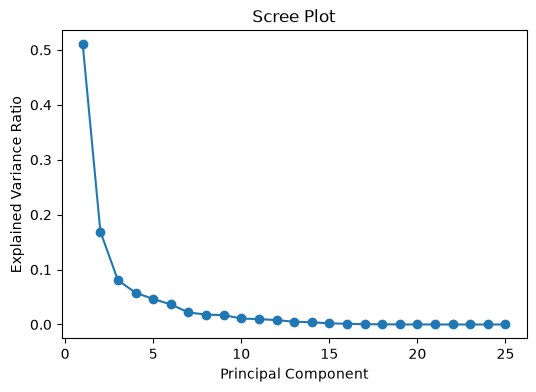

In [22]:
explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_var)+1),
         explained_var,
         marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()

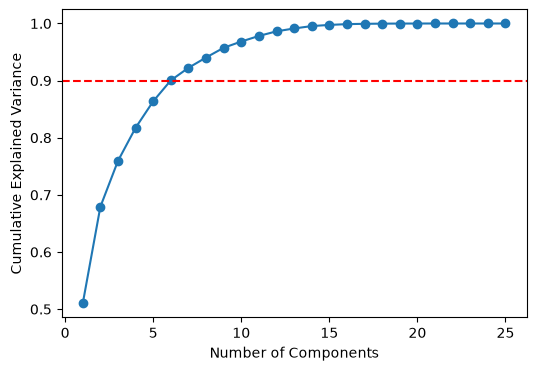

In [23]:
cum_var = np.cumsum(explained_var)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum_var)+1),
         cum_var,
         marker="o")
plt.axhline(0.90, color="red", linestyle="--")
# "How many latent dimensions explain 90% of the variation?"

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

In [24]:
loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f"PC{i+1}" for i in range(len(X.columns))]
)

loadings

,psd_size_at_d10_mm,psd_size_at_d20_mm,psd_size_at_d30_mm,psd_size_at_d40_mm,psd_size_at_d50_mm,psd_size_at_d60_mm,psd_size_at_d70_mm,psd_size_at_d80_mm,psd_size_at_d90_mm,psd_size_at_d95_mm,...,proctor_diam_mm,grain_density_g_cm3,clay,silt,sand,gravel,fine-grained,feat_cu,feat_cc,feat_log_cu
PC1,2.132846e-01,2.053630e-01,2.017341e-01,2.238271e-01,2.404227e-01,2.499047e-01,2.498787e-01,2.526528e-01,2.510725e-01,2.428097e-01,...,2.199646e-01,9.558914e-03,-0.167129,-0.191796,-0.045337,0.265617,-2.122375e-01,-3.309892e-02,-9.140626e-02,-6.472195e-02
PC2,1.651111e-01,2.146881e-02,-3.734490e-02,-8.939851e-02,-1.274333e-01,-1.532232e-01,-1.628312e-01,-1.575597e-01,-1.352578e-01,-1.172727e-01,...,-1.309009e-01,-8.189764e-02,-0.303290,-0.252812,0.434947,-0.080434,-2.071566e-01,-1.166246e-01,-2.017514e-02,-3.879550e-01
PC3,2.187546e-01,4.390615e-01,4.615891e-01,3.759651e-01,2.400034e-01,8.043284e-02,-4.998223e-02,-1.345260e-01,-2.003525e-01,-2.220220e-01,...,-1.980095e-01,-1.417695e-01,0.120136,0.080660,-0.023737,-0.089479,6.774765e-02,5.412599e-02,1.801024e-01,-6.627645e-02
PC4,1.665252e-01,-1.699452e-02,-6.791564e-02,-7.228128e-02,-6.030144e-02,-4.813321e-02,-3.744569e-02,-1.724743e-02,-4.122798e-03,4.219834e-03,...,1.135998e-02,-3.179712e-01,0.286913,-0.170039,0.050153,-0.001704,-1.958523e-01,5.795623e-01,-4.360513e-01,9.934322e-02
PC5,-1.555311e-01,-1.494856e-02,2.479502e-02,2.976734e-02,2.767333e-02,3.498096e-02,3.228100e-02,1.201578e-02,-9.662663e-03,-4.122704e-03,...,-3.578364e-02,2.932939e-01,-0.036241,-0.297642,0.273521,0.014028,1.300941e-01,4.619279e-01,5.231001e-01,3.856871e-01
PC6,1.105337e-01,7.780804e-02,3.787242e-02,9.292991e-03,2.657970e-03,1.529993e-02,1.662640e-02,-1.329056e-02,-6.665149e-02,-1.186851e-01,...,-2.381860e-02,8.368254e-01,0.098486,-0.031615,0.006748,-0.013819,-1.948623e-01,9.286297e-02,-3.553939e-01,-1.430248e-01
PC7,-3.096077e-02,2.910981e-02,3.674446e-02,7.334921e-03,-4.460255e-03,5.040276e-02,9.386588e-02,4.894672e-02,-8.491033e-02,-1.863790e-01,...,2.363167e-01,-2.468515e-01,0.132224,-0.333406,0.226244,0.029337,-1.458548e-01,-1.795986e-01,-7.976679e-02,1.523242e-01
PC8,-2.218062e-01,-7.125014e-02,3.569875e-03,7.664723e-02,1.123716e-01,1.417114e-01,1.380348e-01,6.255784e-02,-7.611830e-02,-1.757979e-01,...,2.927280e-02,-1.302687e-01,-0.416967,0.250762,-0.057624,-0.014839,6.844218e-02,4.865878e-01,-2.537978e-01,-5.850359e-02
PC9,2.699060e-01,2.367668e-01,1.234559e-01,-1.107942e-01,-2.633168e-01,-3.335265e-01,-2.877592e-01,-1.475224e-01,7.578302e-02,1.584515e-01,...,2.530341e-01,-1.729731e-03,-0.063512,0.084304,-0.154838,0.093912,-4.358801e-02,3.348581e-01,2.345772e-01,-2.144533e-01
PC10,8.408451e-02,-1.171478e-01,-1.514833e-01,-1.190152e-01,-4.502360e-02,4.046466e-02,8.456247e-02,4.293884e-02,-1.594476e-01,-3.030317e-01,...,4.805145e-01,4.180926e-03,0.028861,0.084114,-0.253808,0.153527,-3.025420e-01,-1.160160e-02,3.409811e-01,-5.266766e-02


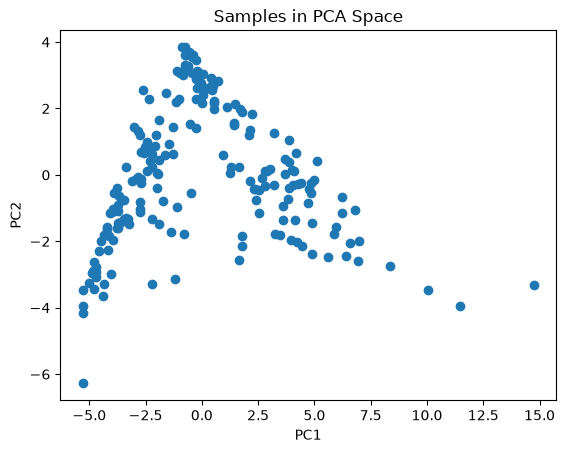

In [25]:
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Samples in PCA Space")
plt.show()

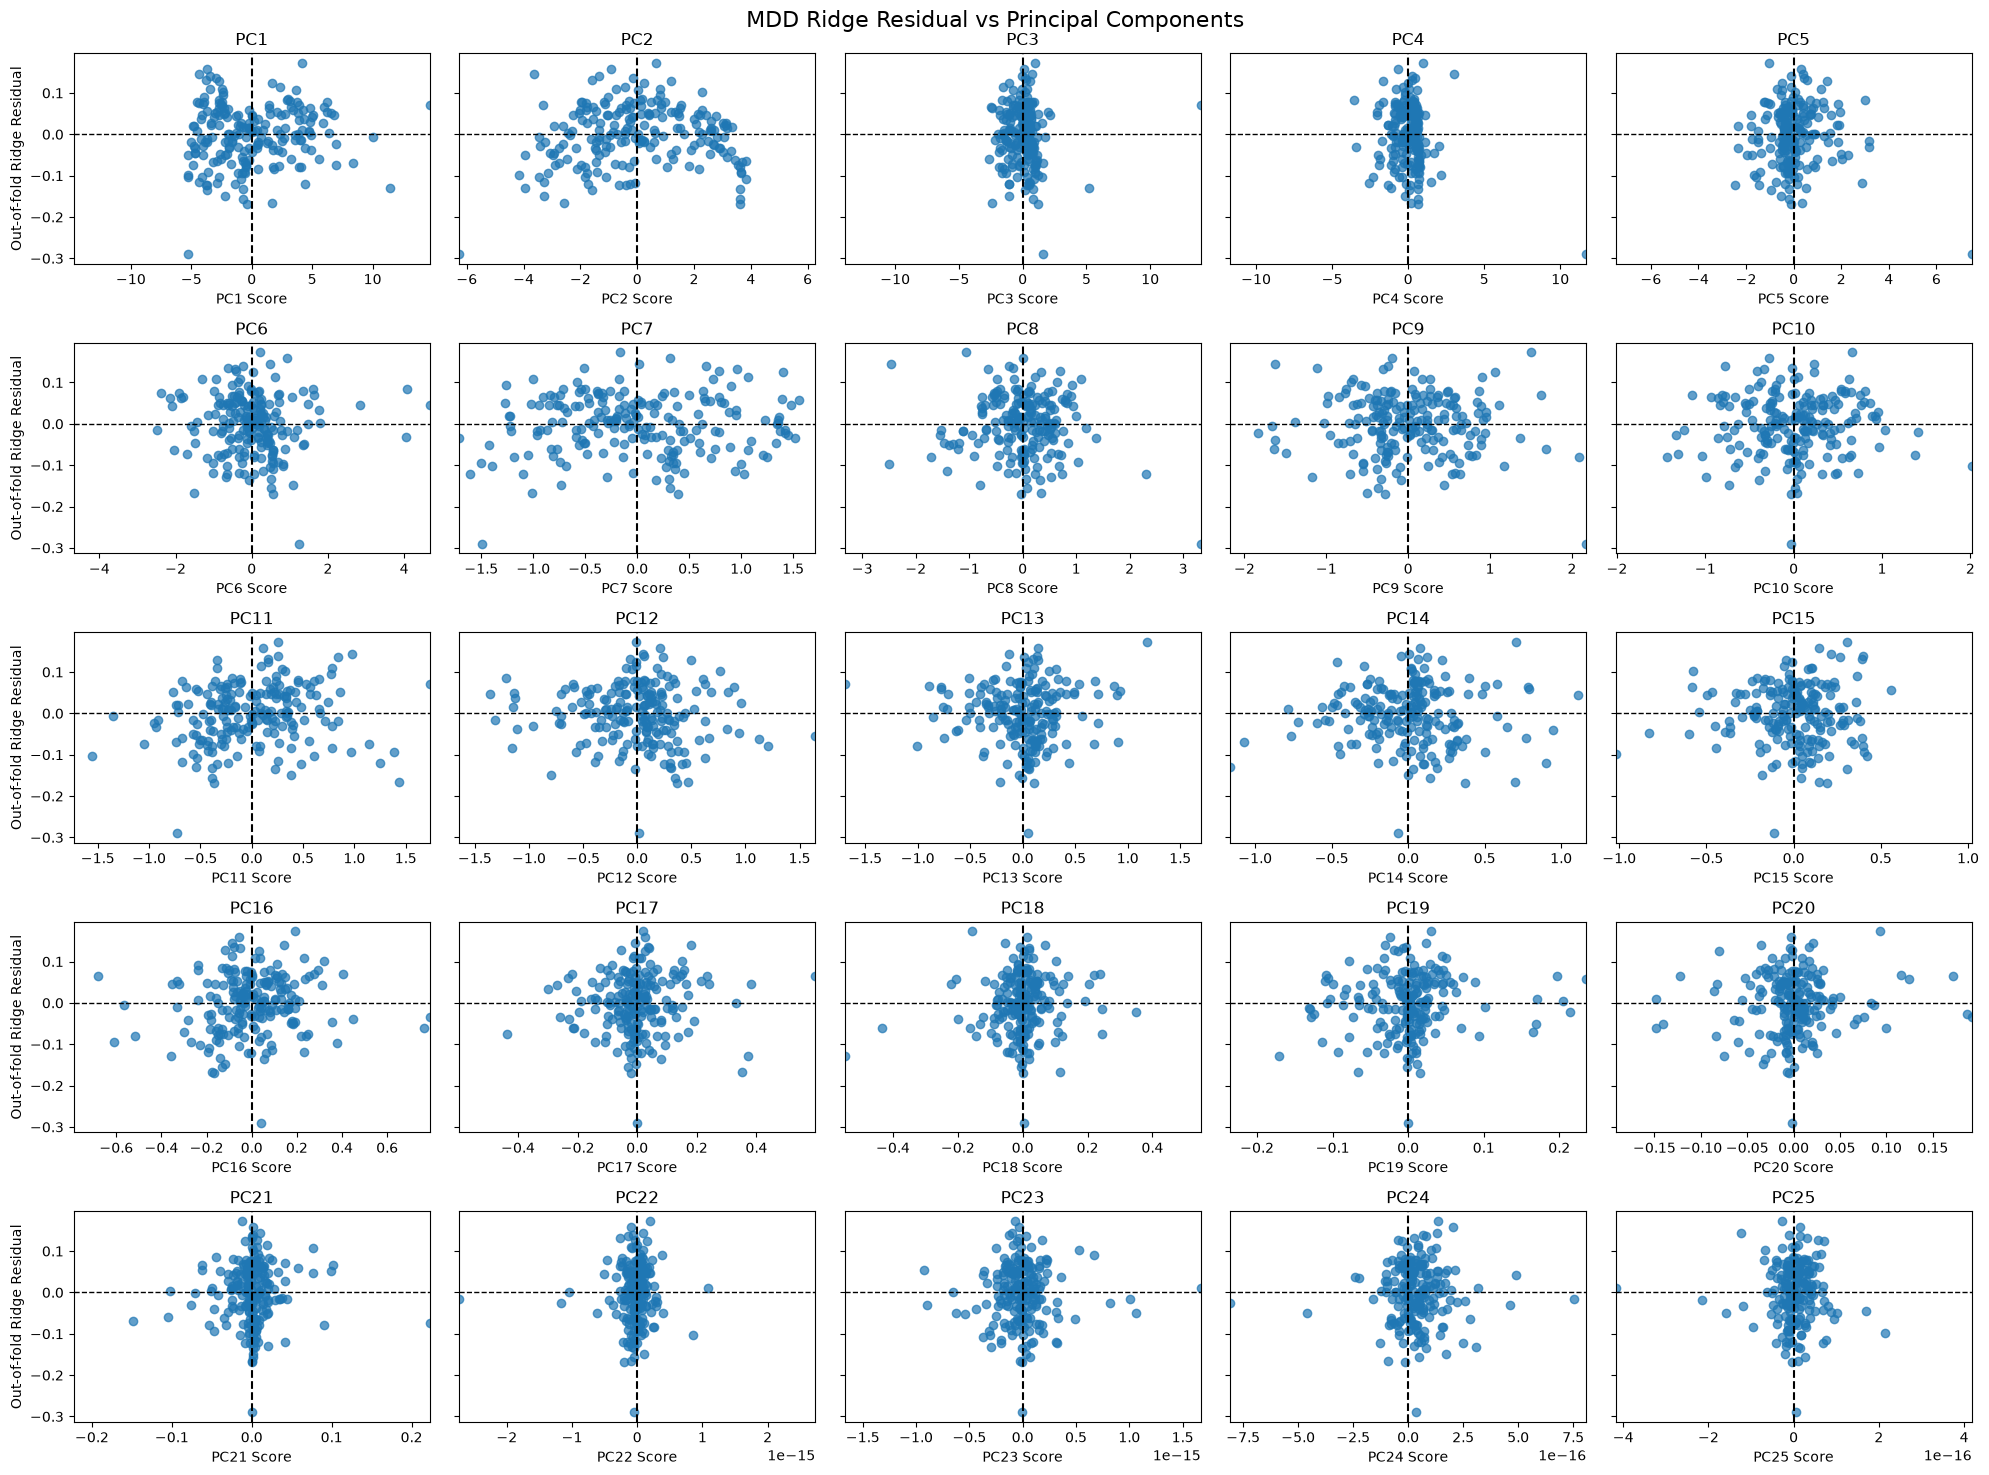

In [26]:
n_pcs = X_pca.shape[1]

n_cols = 5
n_rows = math.ceil(n_pcs / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4*n_cols, 3*n_rows),
    sharey=True,
)

axes = axes.flatten()

for i in range(n_pcs):
    axes[i].scatter(
        X_pca[:, i],
        df_reg["mdd_ridge_res"],
        alpha=0.7
    )
    axes[i].axhline(0, linestyle="--", color="black", linewidth=1)
    axes[i].axvline(0, linestyle="--", color="black")

    max_abs = np.max(np.abs(X_pca[:, i]))
    axes[i].set_xlim(-max_abs, max_abs)
    
    axes[i].set_title(f"PC{i+1}")
    axes[i].set_xlabel(f"PC{i+1} Score")

# Only label the left-most plots
for ax in axes[::n_cols]:
    ax.set_ylabel("Out-of-fold Ridge Residual")

# Remove any unused axes
for j in range(n_pcs, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("MDD Ridge Residual vs Principal Components", fontsize=16)
plt.tight_layout()
plt.show()

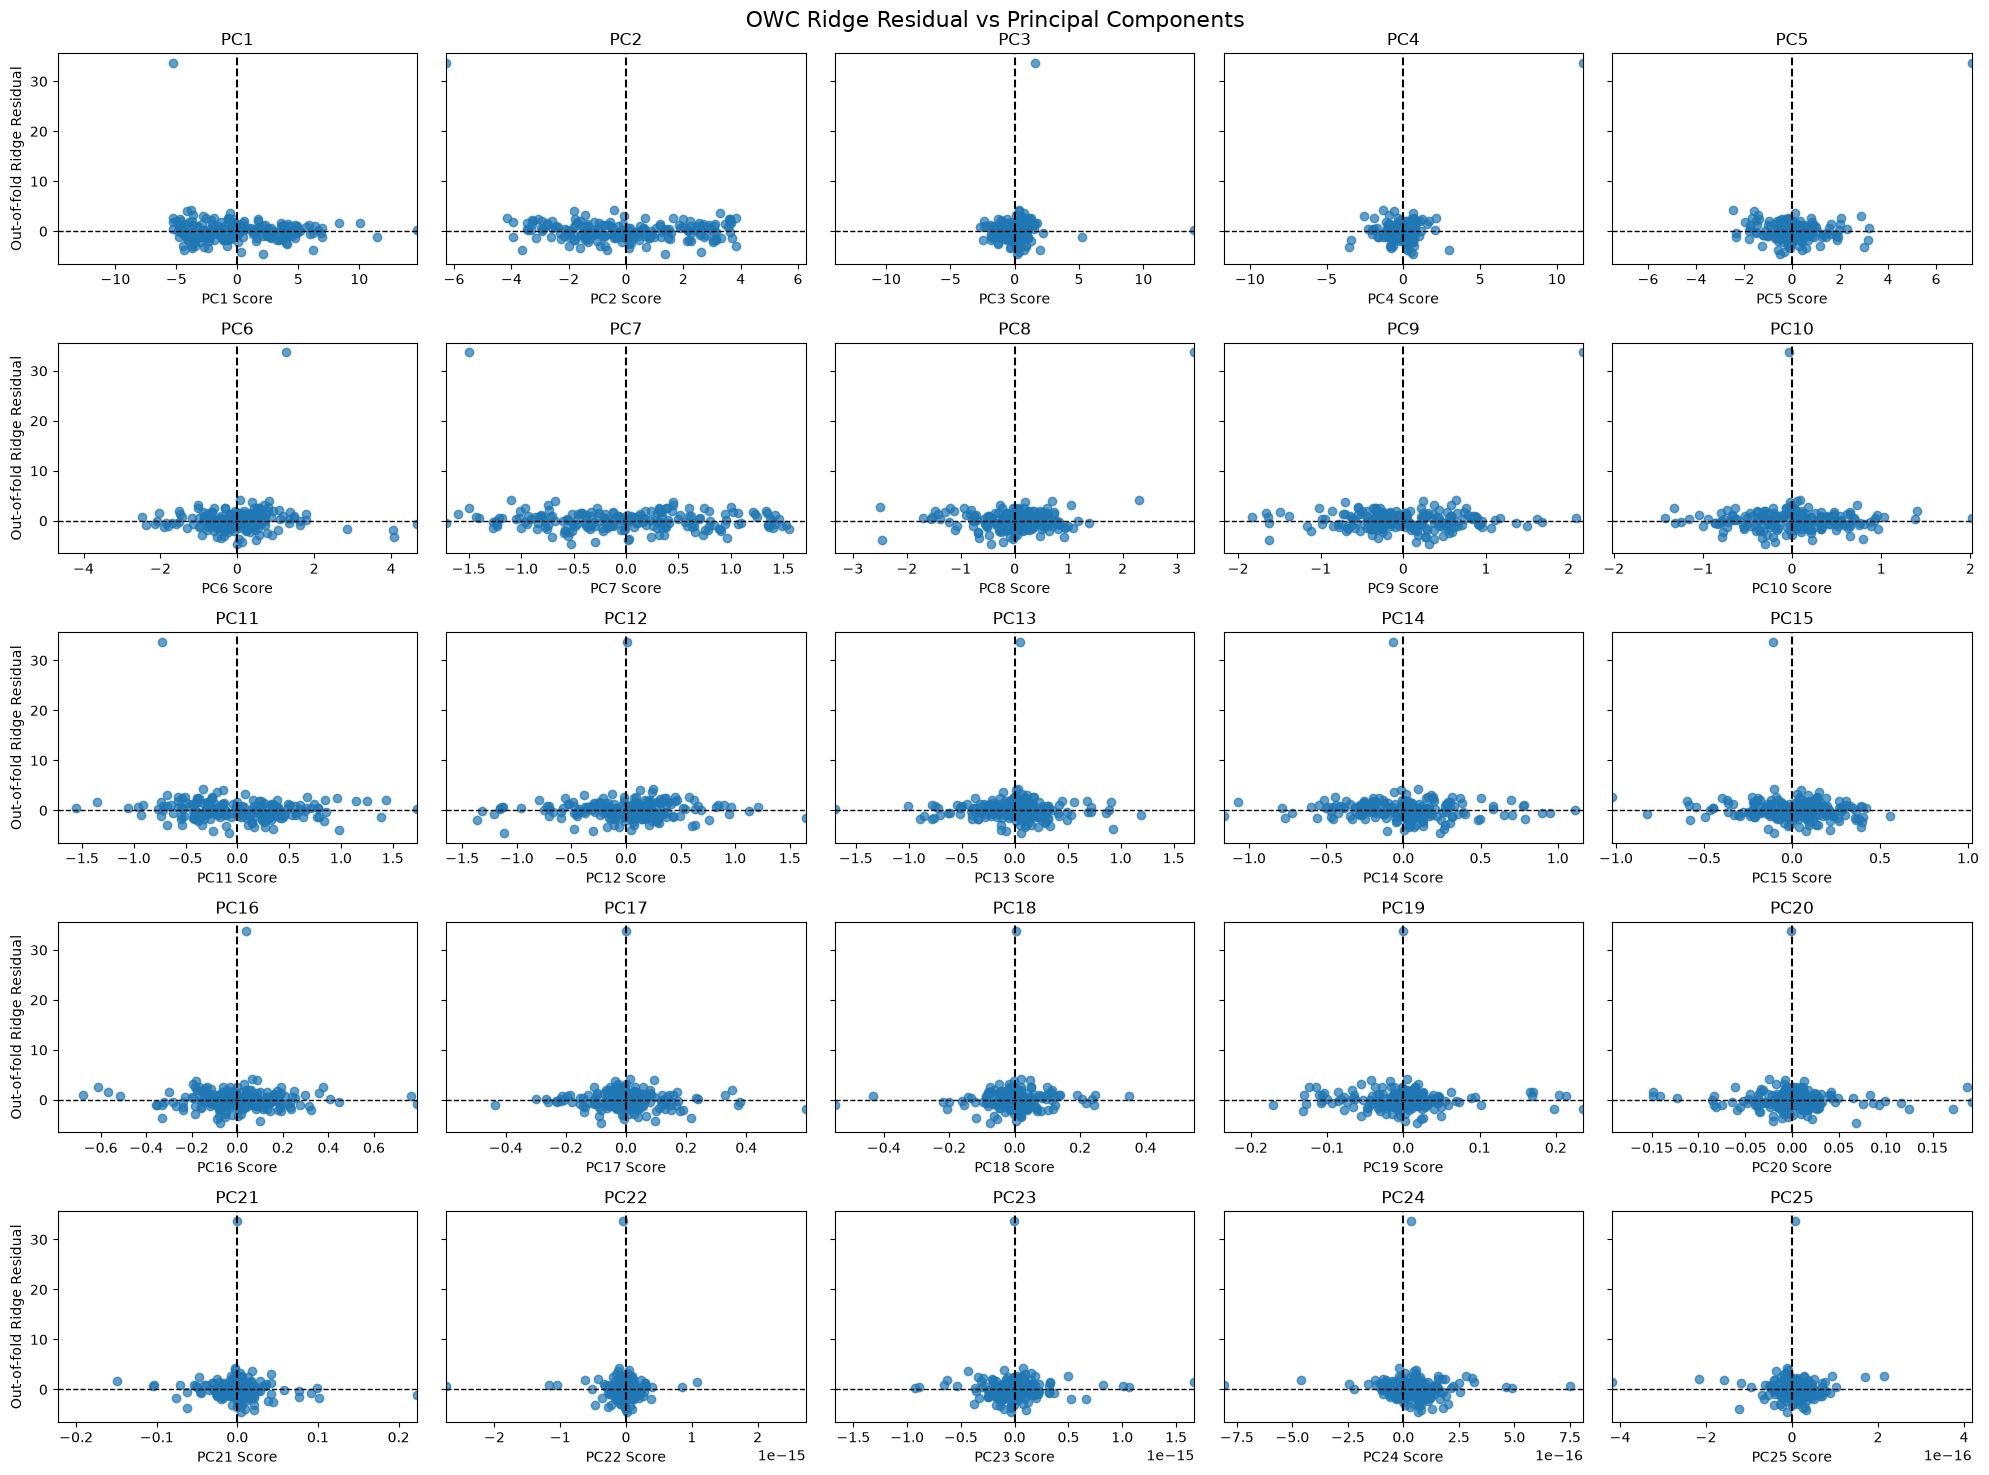

In [27]:
n_pcs = X_pca.shape[1]

n_cols = 5
n_rows = math.ceil(n_pcs / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4*n_cols, 3*n_rows),
    sharey=True,
)

axes = axes.flatten()

for i in range(n_pcs):
    axes[i].scatter(
        X_pca[:, i],
        df_reg["owc_ridge_res"],
        alpha=0.7
    )
    axes[i].axhline(0, linestyle="--", color="black", linewidth=1)
    axes[i].axvline(0, linestyle="--", color="black")

    max_abs = np.max(np.abs(X_pca[:, i]))
    axes[i].set_xlim(-max_abs, max_abs)
    
    axes[i].set_title(f"PC{i+1}")
    axes[i].set_xlabel(f"PC{i+1} Score")

# Only label the left-most plots
for ax in axes[::n_cols]:
    ax.set_ylabel("Out-of-fold Ridge Residual")

# Remove any unused axes
for j in range(n_pcs, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("OWC Ridge Residual vs Principal Components", fontsize=16)
plt.tight_layout()
plt.show()

In [28]:
# "Does the Ridge residual change systematically as PC(n) changes?"
# spearmanr evaluates the strength and direction of the association between two ranked or continuous variables

results = []

residual_mdd = df_reg["mdd_ridge_res"]
residual_owc = df_reg["owc_ridge_res"]

for i in range(X_pca.shape[1]):
    rho_mdd, p_mdd = spearmanr(X_pca[:, i], residual_mdd)
    rho_owc, p_owc = spearmanr(X_pca[:, i], residual_owc)

    results.append({
        "PC": f"PC{i+1}",
        "rho_mdd": rho_mdd,
        "p_mdd": p_mdd,
        "rho_owc": rho_owc,
        "p_owc": p_owc,
    })

residual_pc_corr = (pd.DataFrame(results).set_index("PC").round(3))

residual_pc_corr

,rho_mdd,p_mdd,rho_owc,p_owc
PC,,,,
PC1,0.068,0.335,-0.006,0.936
PC2,0.052,0.464,-0.058,0.414
PC3,-0.097,0.172,0.113,0.111
PC4,-0.147,0.038,0.119,0.091
PC5,0.098,0.166,-0.089,0.207
PC6,-0.100,0.156,0.151,0.033
PC7,-0.012,0.867,-0.040,0.575
PC8,-0.002,0.972,-0.034,0.635
PC9,-0.014,0.843,-0.011,0.879


Linear latent structure exists and is captured well by Ridge. Residual analysis shows no remaining dependence on individual principal components.

## Nonlinearity
Are the remaining errors due to nonlinear relationships?

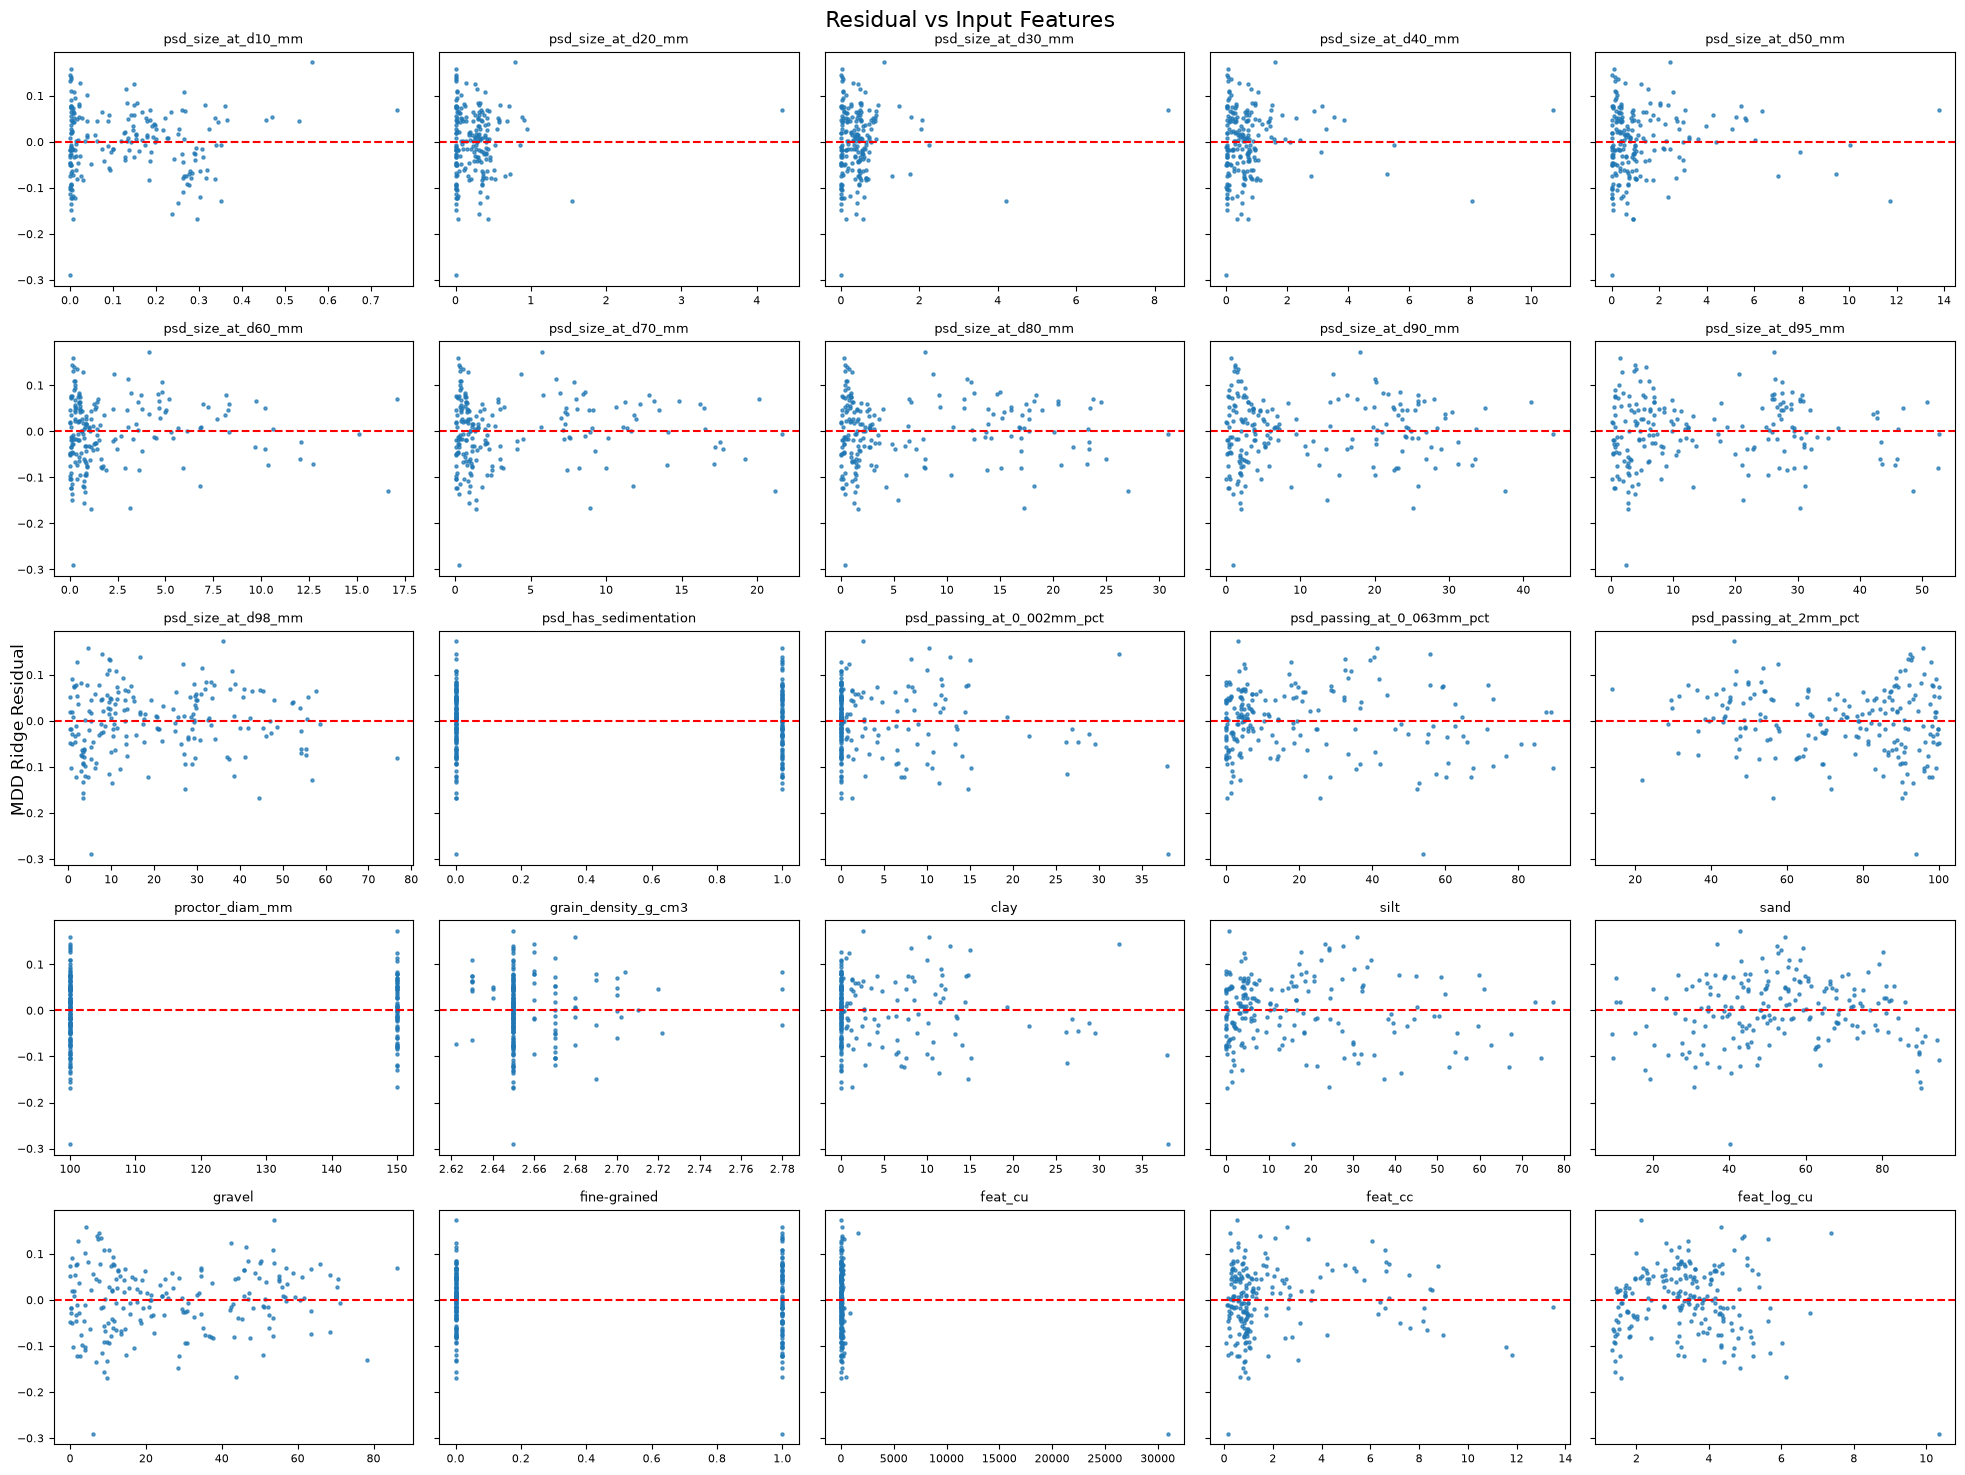

In [29]:
X = X[params_av]

n_features = len(X.columns)

n_cols = 5
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4*n_cols, 3*n_rows),
    sharey=True
)

axes = axes.flatten()

for i, col in enumerate(X.columns):
    axes[i].scatter(
        X[col],
        residual_mdd,
        alpha=0.7,
        s=5
    )
    axes[i].axhline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=8)

# Remove empty subplots
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

fig.supylabel("MDD Ridge Residual")
fig.suptitle("Residual vs Input Features", fontsize=16)

plt.tight_layout()
plt.show()

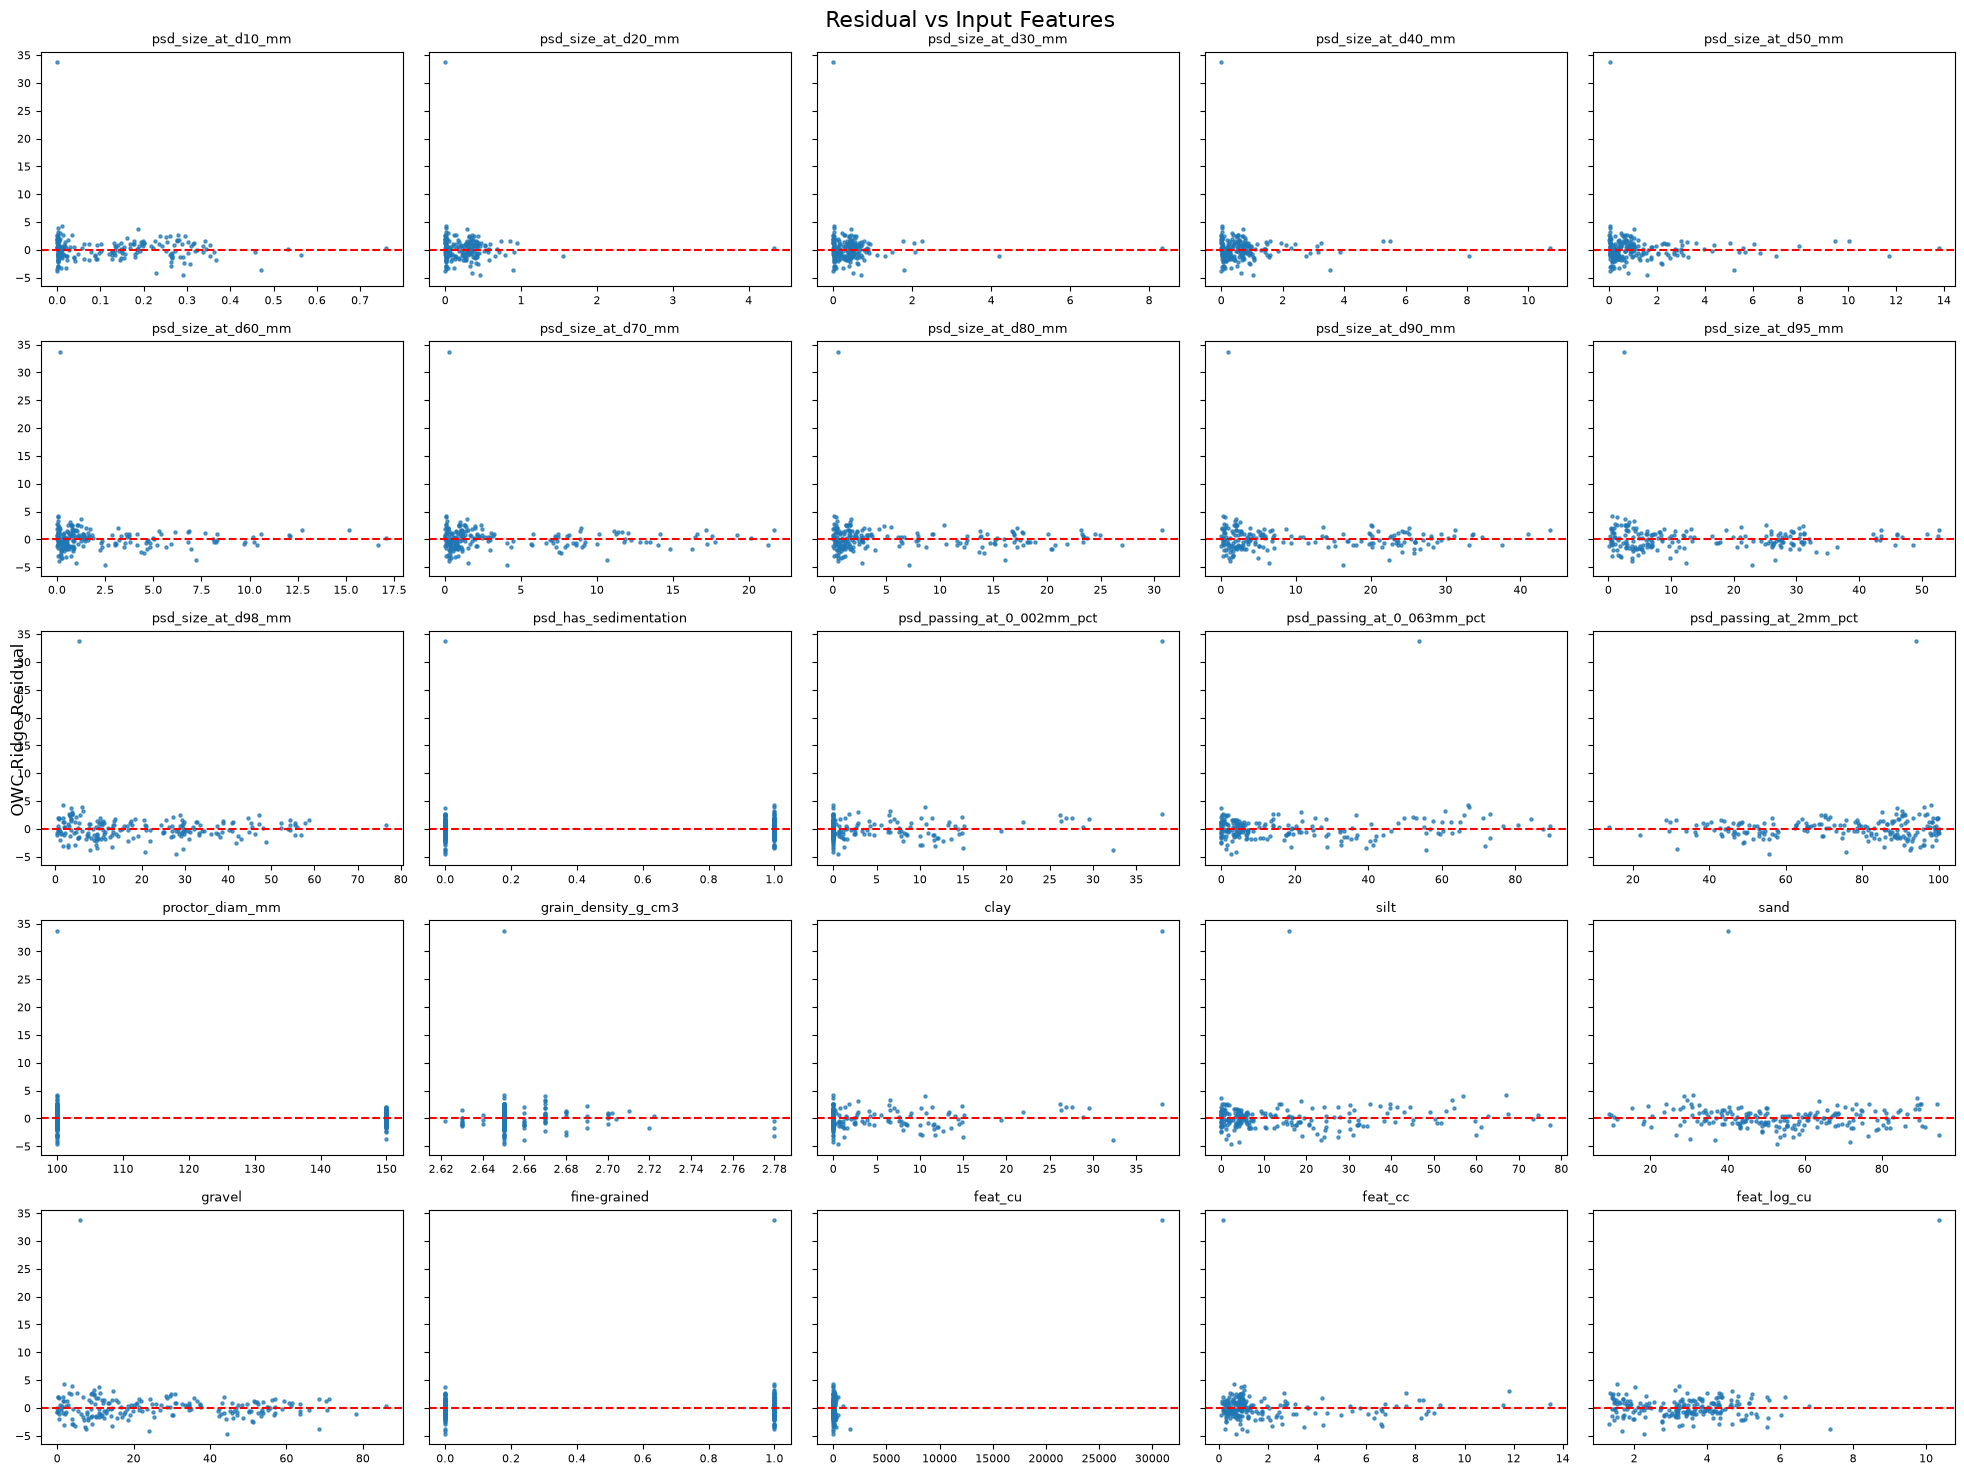

In [30]:
X = X[params_av]

n_features = len(X.columns)

n_cols = 5
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4*n_cols, 3*n_rows),
    sharey=True
)

axes = axes.flatten()

for i, col in enumerate(X.columns):
    axes[i].scatter(
        X[col],
        residual_owc,
        alpha=0.7,
        s=5
    )
    axes[i].axhline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=8)

# Remove empty subplots
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

fig.supylabel("OWC Ridge Residual")
fig.suptitle("Residual vs Input Features", fontsize=16)

plt.tight_layout()
plt.show()

### XGBoost

In [31]:
feature_cols = [
    col for col in params_av
    if col not in [
        "proctor_mdd_g_cm3",
        "proctor_owc_pct"
    ]
]

X = df[feature_cols].copy()

y_mdd = df["proctor_mdd_g_cm3"].copy()
y_owc = df["proctor_owc_pct"].copy()

In [32]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

mdd_oof_pred = np.full(len(X), np.nan)
owc_oof_pred = np.full(len(X), np.nan)

for fold, (train_idx, val_idx) in enumerate(cv.split(X), start=1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_mdd_train = y_mdd.iloc[train_idx]
    y_mdd_val = y_mdd.iloc[val_idx]

    y_owc_train = y_owc.iloc[train_idx]
    y_owc_val = y_owc.iloc[val_idx]

    # Conservative baseline to reduce overfitting on a small dataset
    mdd_model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )

    owc_model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )

    mdd_model.fit(X_train, y_mdd_train)
    owc_model.fit(X_train, y_owc_train)

    mdd_train_pred = mdd_model.predict(X_train)
    mdd_val_pred = mdd_model.predict(X_val)

    owc_train_pred = owc_model.predict(X_train)
    owc_val_pred = owc_model.predict(X_val)

    mdd_oof_pred[val_idx] = mdd_val_pred
    owc_oof_pred[val_idx] = owc_val_pred

    results.append({
        "Fold": f"Fold {fold}",
        "MDD train R2 (xgb)": r2_score(y_mdd_train, mdd_train_pred),
        "MDD val R2 (xgb)": r2_score(y_mdd_val, mdd_val_pred),
        "OWC train R2 (xgb)": r2_score(y_owc_train, owc_train_pred),
        "OWC val R2 (xgb)": r2_score(y_owc_val, owc_val_pred)
    })

results_df = pd.DataFrame(results).set_index("Fold")

In [33]:
results_df.loc["Mean"] = results_df.mean()
results_df.loc["Std"] = results_df.iloc[:-1].std()

results_df.round(4)

,MDD train R2 (xgb),MDD val R2 (xgb),OWC train R2 (xgb),OWC val R2 (xgb)
Fold,,,,
Fold 1,0.9832,0.8323,0.9825,0.7523
Fold 2,0.9839,0.7836,0.9778,0.8575
Fold 3,0.9842,0.8286,0.9791,0.7709
Fold 4,0.9818,0.8776,0.9775,0.7662
Fold 5,0.9841,0.8528,0.9778,0.8379
Mean,0.9834,0.8350,0.9790,0.7970
Std,0.0010,0.0347,0.0021,0.0473


In [34]:
df_reg['mdd_xgb'] = mdd_oof_pred
df_reg['owc_xgb'] = owc_oof_pred
df_reg['mdd_xgb_res'] = df_reg['proctor_mdd_g_cm3'] - df_reg['mdd_xgb']
df_reg['owc_xgb_res'] = df_reg['proctor_owc_pct'] - df_reg['owc_xgb']
df_reg['mdd_xgb_res_pct'] = (df_reg['proctor_mdd_g_cm3'] - df_reg['mdd_xgb']) / df_reg['proctor_mdd_g_cm3']
df_reg['owc_xgb_res_pct'] = (df_reg['proctor_owc_pct'] - df_reg['owc_xgb']) / df_reg['proctor_owc_pct']

#### Feature Importance

In [35]:
def make_xgb_model():
    return XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )

xgb_mdd = make_xgb_model()
xgb_owc = make_xgb_model()

xgb_mdd.fit(X, y_mdd)
xgb_owc.fit(X, y_owc)

def get_gain_importance(model, feature_names):
    gain_dict = model.get_booster().get_score(importance_type="gain")

    importance = pd.Series({feature: gain_dict.get(feature, 0.0) for feature in feature_names}, name="gain")

    # Convert raw gains into proportions
    if importance.sum() > 0:
        importance = importance / importance.sum()

    return importance.sort_values(ascending=False)

mdd_gain = get_gain_importance(xgb_mdd, X.columns)
owc_gain = get_gain_importance(xgb_owc, X.columns)

print("MDD gain importance")
display(mdd_gain.to_frame().head(15))

print("OWC gain importance")
display(owc_gain.to_frame().head(15))

MDD gain importance


,gain
psd_size_at_d70_mm,0.172751
psd_size_at_d90_mm,0.108478
psd_size_at_d60_mm,0.101136
psd_size_at_d95_mm,0.089806
psd_size_at_d98_mm,0.087436
psd_size_at_d50_mm,0.080921
feat_cc,0.048516
feat_cu,0.048241
psd_size_at_d40_mm,0.039397
psd_passing_at_2mm_pct,0.028967


OWC gain importance


,gain
psd_size_at_d50_mm,0.269005
psd_size_at_d40_mm,0.187569
psd_passing_at_0_063mm_pct,0.141034
psd_size_at_d70_mm,0.072143
psd_size_at_d60_mm,0.062663
psd_size_at_d30_mm,0.052314
psd_passing_at_2mm_pct,0.031689
psd_size_at_d80_mm,0.022822
psd_size_at_d98_mm,0.021617
silt,0.018158


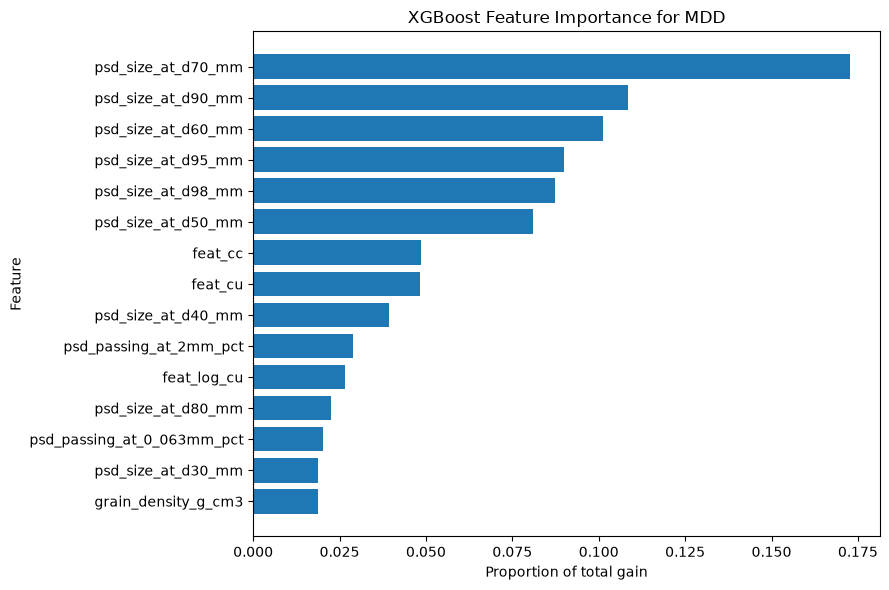

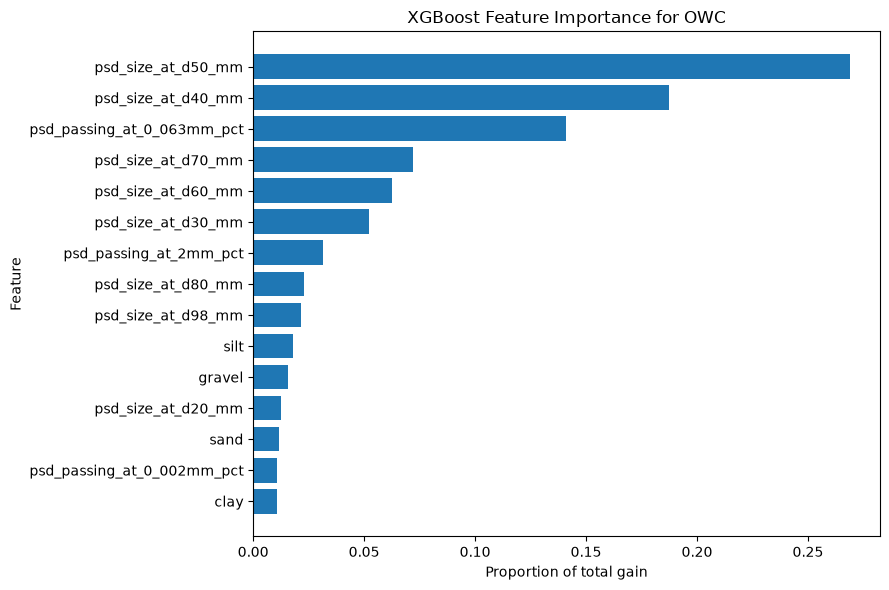

,MDD gain,OWC gain
feat_cu,0.048241,0.006469
feat_cc,0.048516,0.010555
feat_log_cu,0.026623,0.007105


In [36]:
def plot_gain_importance(
    importance,
    title,
    top_n=15
):
    top = importance.head(top_n).sort_values()

    plt.figure(figsize=(9, 6))
    plt.barh(top.index, top.values)

    plt.xlabel("Proportion of total gain")
    plt.ylabel("Feature")
    plt.title(title)

    plt.tight_layout()
    plt.show()

plot_gain_importance(mdd_gain, "XGBoost Feature Importance for MDD")
plot_gain_importance(owc_gain, "XGBoost Feature Importance for OWC")

engineered_features = ["feat_cu", "feat_cc", "feat_log_cu"]

engineered_importance = pd.DataFrame({
    "MDD gain": mdd_gain.reindex(engineered_features, fill_value=0),
    "OWC gain": owc_gain.reindex(engineered_features, fill_value=0)
})

engineered_importance

#### SHAP

In [37]:
mdd_explainer = shap.TreeExplainer(xgb_mdd)
owc_explainer = shap.TreeExplainer(xgb_owc)

mdd_shap_values = mdd_explainer(X)
owc_shap_values = owc_explainer(X)

In [38]:
def plot_shap_summary(model, X, target_name, max_display=15):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Beeswarm
    shap.plots.beeswarm(shap_values, max_display=max_display, show=False, ax=axes[0], plot_size=None)
    axes[0].set_title(f"SHAP Summary Plot for {target_name}")

    # Global bar importance
    shap.plots.bar(shap_values, max_display=max_display, show=False, ax=axes[1])
    axes[1].set_title(f"Global SHAP Importance for {target_name}")

    plt.tight_layout()
    plt.show()

    return shap_values

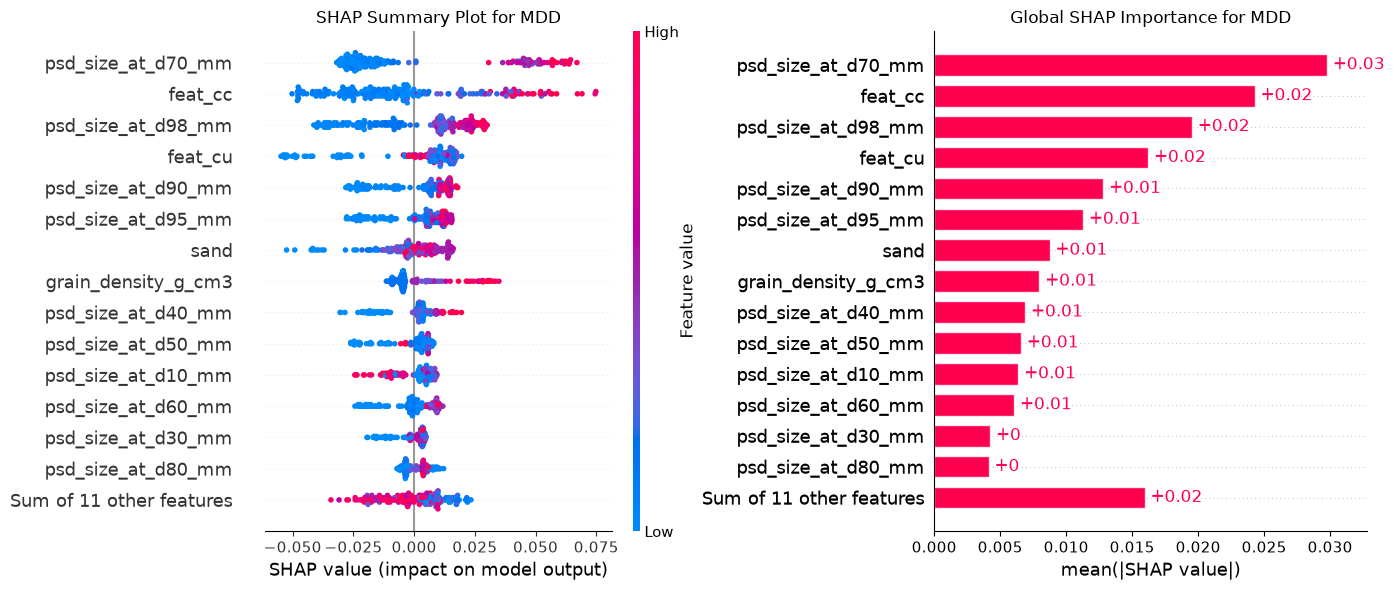

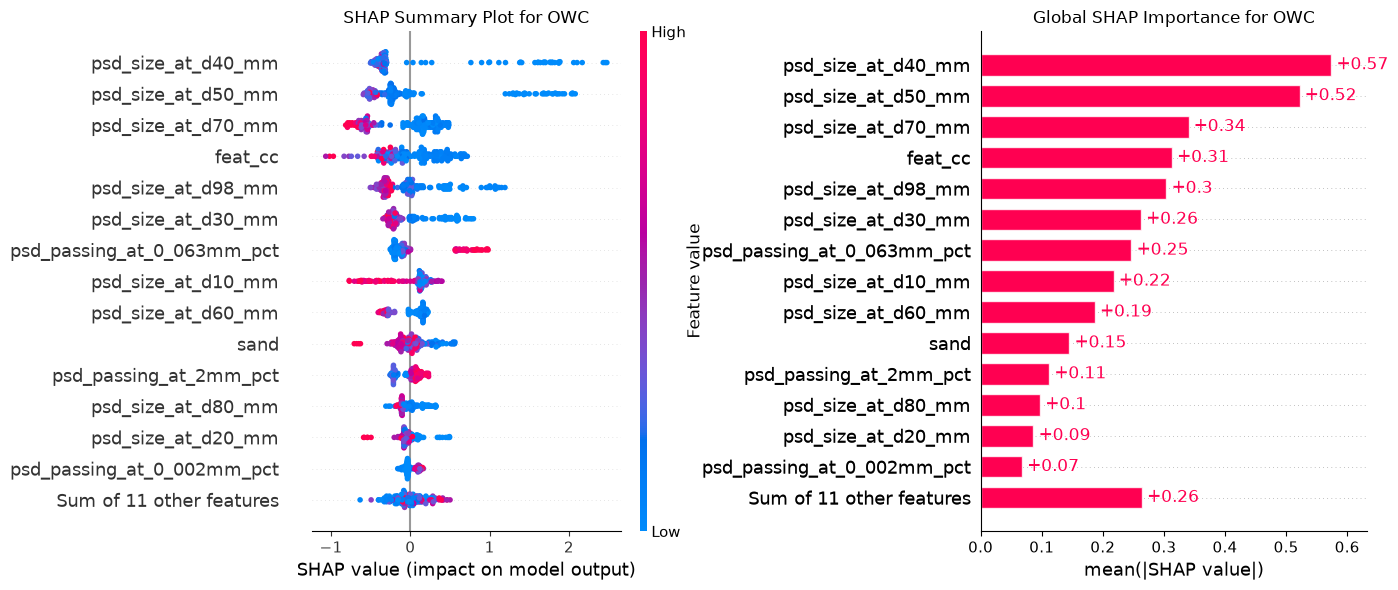

In [39]:
mdd_shap_values = plot_shap_summary(xgb_mdd, X, target_name="MDD")
owc_shap_values = plot_shap_summary(xgb_owc, X, target_name="OWC")

### Gaussian Process Regression

In [40]:
feature_cols = [
    col for col in params_av
    if col not in [
        "proctor_mdd_g_cm3",
        "proctor_owc_pct"
    ]
]

X = df[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan)

y_mdd = df["proctor_mdd_g_cm3"].copy()
y_owc = df["proctor_owc_pct"].copy()

In [41]:
def make_gpr_model(n_features):
    kernel = (
        ConstantKernel(constant_value=1.0, constant_value_bounds=(1e-2, 1e2))
        * RBF(length_scale=np.ones(n_features), length_scale_bounds=(1e-2, 1e2))
        + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))
    )

    return GaussianProcessRegressor(kernel=kernel, alpha=1e-8, normalize_y=False, n_restarts_optimizer=3, random_state=42)

In [42]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

mdd_oof_pred = np.full(len(X), np.nan)
owc_oof_pred = np.full(len(X), np.nan)
mdd_oof_std = np.full(len(X), np.nan)
owc_oof_std = np.full(len(X), np.nan)

for fold, (train_idx, val_idx) in enumerate(cv.split(X), start=1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_mdd_train = y_mdd.iloc[train_idx]
    y_mdd_val = y_mdd.iloc[val_idx]

    y_owc_train = y_owc.iloc[train_idx]
    y_owc_val = y_owc.iloc[val_idx]

    # Preprocess X
    x_preprocessor = Pipeline([("scaler", StandardScaler())])

    X_train_scaled = x_preprocessor.fit_transform(X_train)
    X_val_scaled = x_preprocessor.transform(X_val)

    # Standardize targets
    mdd_scaler = StandardScaler()
    owc_scaler = StandardScaler()

    y_mdd_train_scaled = mdd_scaler.fit_transform(y_mdd_train.to_numpy().reshape(-1, 1)).ravel()
    y_owc_train_scaled = owc_scaler.fit_transform(y_owc_train.to_numpy().reshape(-1, 1)).ravel()

    # Fit GPR models
    gpr_mdd = make_gpr_model(n_features=X_train_scaled.shape[1])
    gpr_owc = make_gpr_model(n_features=X_train_scaled.shape[1])
    gpr_mdd.fit(X_train_scaled, y_mdd_train_scaled)
    gpr_owc.fit(X_train_scaled, y_owc_train_scaled)

    # Predictions
    mdd_train_pred_scaled = gpr_mdd.predict(X_train_scaled)
    mdd_val_pred_scaled, mdd_val_std_scaled = (gpr_mdd.predict(X_val_scaled, return_std=True))
    owc_train_pred_scaled = gpr_owc.predict(X_train_scaled)
    owc_val_pred_scaled, owc_val_std_scaled = (gpr_owc.predict(X_val_scaled, return_std=True))

    # Transform predictions back to original units
    mdd_train_pred = mdd_scaler.inverse_transform(mdd_train_pred_scaled.reshape(-1, 1)).ravel()
    mdd_val_pred = mdd_scaler.inverse_transform(mdd_val_pred_scaled.reshape(-1, 1)).ravel()
    owc_train_pred = owc_scaler.inverse_transform(owc_train_pred_scaled.reshape(-1, 1)).ravel()
    owc_val_pred = owc_scaler.inverse_transform(owc_val_pred_scaled.reshape(-1, 1)).ravel()

    mdd_oof_pred[val_idx] = mdd_val_pred
    owc_oof_pred[val_idx] = owc_val_pred

    # Convert predictive standard deviation back to target units
    mdd_val_std = (mdd_val_std_scaled * mdd_scaler.scale_[0])
    owc_val_std = (owc_val_std_scaled * owc_scaler.scale_[0])
    mdd_oof_std[val_idx] = mdd_val_std
    owc_oof_std[val_idx] = owc_val_std

    results.append({
        "Fold": f"Fold {fold}",
        "MDD train R2 (gpr)": r2_score(y_mdd_train, mdd_train_pred),
        "MDD val R2 (gpr)": r2_score(y_mdd_val, mdd_val_pred),
        "MDD val RMSE (gpr)": mean_squared_error(y_mdd_val, mdd_val_pred) ** 0.5,
        "MDD mean pred std": mdd_val_std.mean(),
        "OWC train R2 (gpr)": r2_score(y_owc_train, owc_train_pred),
        "OWC val R2 (gpr)": r2_score(y_owc_val, owc_val_pred),
        "OWC val RMSE (gpr)": mean_squared_error(y_owc_val, owc_val_pred) ** 0.5,
        "OWC mean pred std": owc_val_std.mean()
    })

df_reg["mdd_gpr"] = mdd_oof_pred
df_reg["owc_gpr"] = owc_oof_pred

df_reg["mdd_gpr_std"] = mdd_oof_std
df_reg["owc_gpr_std"] = owc_oof_std

/Users/junkyunglee/Codes/Co-op/proctor-prediction-challenge/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/junkyunglee/Codes/Co-op/proctor-prediction-challenge/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/junkyunglee/Codes/Co-op/proctor-prediction-challenge/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Incre

In [43]:
df_reg[["mdd_gpr", "owc_gpr", "mdd_gpr_std", "owc_gpr_std"]].isna().sum()

mdd_gpr        0
owc_gpr        0
mdd_gpr_std    0
owc_gpr_std    0
dtype: int64

In [44]:
gpr_results_df = pd.DataFrame(results).set_index("Fold")

gpr_results_df.loc["Mean"] = gpr_results_df.mean()
gpr_results_df.loc["Std"] = (
    gpr_results_df.iloc[:-1].std()
)

gpr_results_df.round(4)

,MDD train R2 (gpr),MDD val R2 (gpr),MDD val RMSE (gpr),MDD mean pred std,OWC train R2 (gpr),OWC val R2 (gpr),OWC val RMSE (gpr),OWC mean pred std
Fold,,,,,,,,
Fold 1,0.9261,0.8109,0.0605,0.0480,0.8837,0.7670,1.4898,1.3032
Fold 2,0.9223,0.8236,0.0569,0.0534,0.8833,0.8319,1.3397,1.4474
Fold 3,0.9298,0.7471,0.0707,0.0493,0.8975,0.6556,1.9867,1.3663
Fold 4,0.9118,0.8278,0.0612,0.0529,0.8735,0.7124,2.0553,1.3786
Fold 5,0.9268,0.8630,0.0479,0.0489,0.8817,0.8088,1.3170,1.3706
Mean,0.9233,0.8145,0.0594,0.0505,0.8840,0.7552,1.6377,1.3732
Std,0.0070,0.0423,0.0082,0.0025,0.0086,0.0718,0.3569,0.0512


In [45]:
df_reg['mdd_gpr'] = mdd_oof_pred
df_reg['owc_gpr'] = owc_oof_pred
df_reg['mdd_gpr_res'] = df_reg['proctor_mdd_g_cm3'] - df_reg['mdd_gpr']
df_reg['owc_gpr_res'] = df_reg['proctor_owc_pct'] - df_reg['owc_gpr']
df_reg['mdd_gpr_res_pct'] = (df_reg['proctor_mdd_g_cm3'] - df_reg['mdd_gpr']) / df_reg['proctor_mdd_g_cm3']
df_reg['owc_gpr_res_pct'] = (df_reg['proctor_owc_pct'] - df_reg['owc_gpr']) / df_reg['proctor_owc_pct']

### Linear Models vs Nonlinear Models

In [46]:
comparison = pd.DataFrame({
    "MDD mean val R2": {
        "Linear": cv_results_lin.loc["Mean", "MDD val R2 (lin)"],
        "Ridge": cv_results_lin.loc["Mean", "MDD val R2 (rid)"],
        "XGBoost": results_df.loc["Mean", "MDD val R2 (xgb)"],
        "GPR": gpr_results_df.loc["Mean", "MDD val R2 (gpr)"]
    },
    "OWC mean val R2": {
        "Linear": cv_results_lin.loc["Mean", "OWC val R2 (lin)"],
        "Ridge": cv_results_lin.loc["Mean", "OWC val R2 (rid)"],
        "XGBoost": results_df.loc["Mean", "OWC val R2 (xgb)"],
        "GPR": gpr_results_df.loc["Mean", "OWC val R2 (gpr)"]
    },
    "MDD val std": {
        "Linear": cv_results_lin.loc["Std", "MDD val R2 (lin)"],
        "Ridge": cv_results_lin.loc["Std", "MDD val R2 (rid)"],
        "XGBoost": results_df.loc["Std", "MDD val R2 (xgb)"],
        "GPR": gpr_results_df.loc["Std", "MDD val R2 (gpr)"]
    },
    "OWC val std": {
        "Linear": cv_results_lin.loc["Std", "OWC val R2 (lin)"],
        "Ridge": cv_results_lin.loc["Std", "OWC val R2 (rid)"],
        "XGBoost": results_df.loc["Std", "OWC val R2 (xgb)"],
        "GPR": gpr_results_df.loc["Std", "OWC val R2 (gpr)"]
    }
})

comparison.round(4)

,MDD mean val R2,OWC mean val R2,MDD val std,OWC val std
Linear,0.7440,0.3018,0.0824,0.8789
Ridge,0.7354,0.3877,0.0353,0.7357
XGBoost,0.8350,0.7970,0.0347,0.0473
GPR,0.8145,0.7552,0.0423,0.0718


## Information learned by the models

In [47]:
for c in df_reg.columns:
    if c.endswith('res_pct'):
        df_reg[f'{c}_abs'] = abs(df_reg[c])

In [62]:
col_res_pct = ['mdd_lin_res_pct', 'owc_lin_res_pct', 'mdd_ridge_res_pct', 'owc_ridge_res_pct', 
               'mdd_xgb_res_pct', 'owc_xgb_res_pct','mdd_gpr_res_pct', 'owc_gpr_res_pct']

col_na = ['hyd_cond_kf_m_s', 'hyd_cond_hyd_gradient', 'atterberg_liquid_limit_pct', 
          'atterberg_plastic_limit_pct', 'loss_on_ignition_pct', 'feat_pi']

df_reg[col_res_pct]

,mdd_lin_res_pct,owc_lin_res_pct,mdd_ridge_res_pct,owc_ridge_res_pct,mdd_xgb_res_pct,owc_xgb_res_pct,mdd_gpr_res_pct,owc_gpr_res_pct
0,-0.015050,0.092223,-0.008213,0.073196,-0.010527,0.095873,-0.020860,0.154530
1,-0.027484,0.067069,-0.015498,0.043058,0.011299,-0.038686,0.000254,0.075321
2,-0.023342,0.063798,-0.024398,0.035775,0.000294,0.095337,0.018407,0.107657
3,-0.011251,0.033067,-0.030174,0.088608,-0.048546,0.093186,-0.013887,0.057014
4,-0.046616,0.009810,-0.056446,0.034365,0.016264,-0.036264,-0.095026,0.369576
...,...,...,...,...,...,...,...,...
196,-0.015418,0.060067,-0.007608,-0.028184,-0.021613,-0.006983,-0.015595,-0.033624
197,-0.022779,-0.263809,-0.030166,-0.197195,0.044721,-0.402556,0.021807,-0.383742
198,0.031581,0.043306,0.025630,0.107399,0.016587,0.093902,0.012970,0.114359
199,-0.017576,0.091757,-0.026909,0.131961,-0.001712,0.052363,-0.001276,0.065988


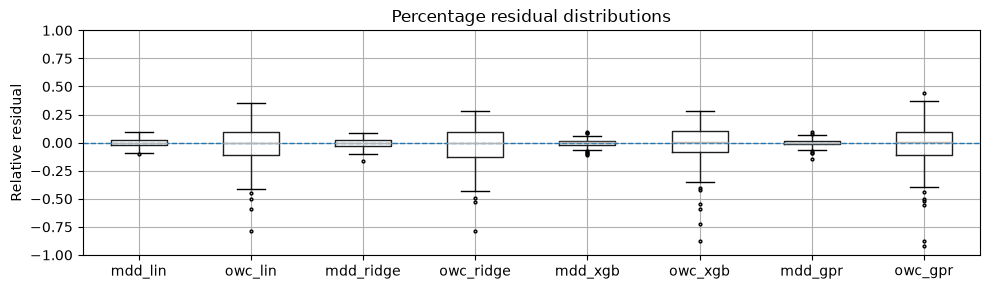

In [49]:
plt.figure(figsize=(10, 3))

df_reg[col_res_pct].boxplot(
    flierprops=dict(marker='o', markersize=2)
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.ylim(-1, 1)

labels = [col.replace("_res_pct", "") for col in col_res_pct]
plt.xticks(range(1, len(labels) + 1), labels)

plt.ylabel("Relative residual")
plt.title("Percentage residual distributions")
plt.tight_layout()
plt.show()

In [50]:
for c in df.columns:
    if len(df[df[c].isna()]) > 0:
       print(c.ljust(30), len(df[df[c].isna()]))

hyd_cond_kf_m_s                140
hyd_cond_hyd_gradient          140
atterberg_liquid_limit_pct     175
atterberg_plastic_limit_pct    175
loss_on_ignition_pct           140
feat_pi                        175


## Imputation Reliability
Before incorporating imputed laboratory measurements into the predictive models, we evaluate whether the missing variables themselves could be reliably reconstructed from universally available measurements.

In [64]:
col_na

['hyd_cond_kf_m_s',
 'hyd_cond_hyd_gradient',
 'atterberg_liquid_limit_pct',
 'atterberg_plastic_limit_pct',
 'loss_on_ignition_pct',
 'feat_pi']

In [ ]:
KF_COL = "hyd_cond_kf_m_s"

kf_predictors = params_av.copy()

# Avoid accidentally using the target itself.
kf_predictors = [col for col in kf_predictors if col != KF_COL]

# Rows where kf is measured and physically valid.
observed_mask = (df[KF_COL].notna() & np.isfinite(df[KF_COL]) & (df[KF_COL] > 0))

X_kf = df.loc[observed_mask, kf_predictors].copy()
y_kf_log = np.log10(df.loc[observed_mask, KF_COL].astype(float))

# This assumes the predictors themselves contain no missing values.
assert X_kf.notna().all().all(), (
    "Some kf predictors contain missing values. "
    "Remove them or place their imputation inside the CV pipeline."
)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

kf_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=400,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

kf_oof_log = cross_val_predict(
    estimator=kf_model,
    X=X_kf,
    y=y_kf_log,
    cv=cv,
    method="predict"
)

print("OOF R², log10(kf):", r2_score(y_kf_log, kf_oof_log))
print("OOF MAE, log10(kf):", mean_absolute_error(y_kf_log, kf_oof_log))
print("OOF RMSE, log10(kf):", mean_squared_error(y_kf_log, kf_oof_log ) ** 0.5)

OOF R², log10(kf): 0.7539705972982416
OOF MAE, log10(kf): 0.820637130655657
OOF RMSE, log10(kf): 1.1453888168104582


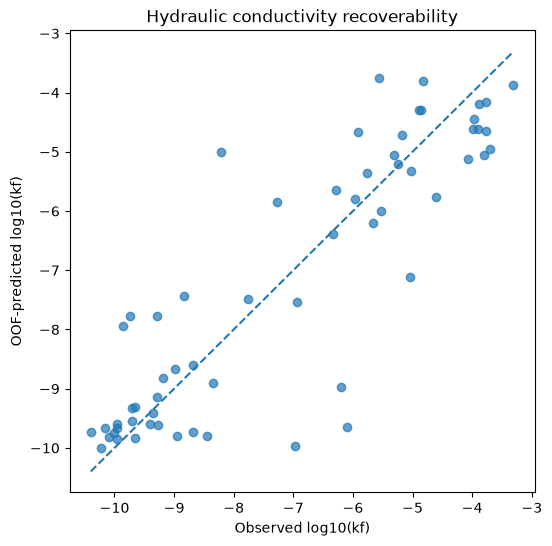

In [69]:
plt.figure(figsize=(6, 6))
plt.scatter(y_kf_log, kf_oof_log, alpha=0.7)

lower = min(y_kf_log.min(), kf_oof_log.min())
upper = max(y_kf_log.max(), kf_oof_log.max())

plt.plot([lower, upper], [lower, upper], linestyle="--")
plt.xlabel("Observed log10(kf)")
plt.ylabel("OOF-predicted log10(kf)")
plt.title("Hydraulic conductivity recoverability")
plt.show()

In [72]:
kf_validation = df.loc[observed_mask].copy()

kf_validation["kf_observed_log10"] = y_kf_log.to_numpy()
kf_validation["kf_oof_log10"] = kf_oof_log
kf_validation["kf_log_residual"] = (
    kf_validation["kf_observed_log10"]
    - kf_validation["kf_oof_log10"]
)
kf_validation["kf_error_factor"] = (
    10 ** np.abs(kf_validation["kf_log_residual"])
)

kf_validation[
    [
        "kf_observed_log10",
        "kf_oof_log10",
        "kf_log_residual",
        "kf_error_factor"
    ]
].describe()

,kf_observed_log10,kf_oof_log10,kf_log_residual,kf_error_factor
count,61.000000,61.000000,61.000000,61.000000
mean,-7.138333,-7.188499,0.050167,122.687065
std,2.328352,2.225735,1.153786,520.556488
min,-10.397940,-9.997068,-3.211792,1.092024
25%,-9.356547,-9.587830,-0.417361,2.003344
50%,-6.976254,-7.481754,-0.114492,3.521893
75%,-5.041149,-5.046234,0.563082,14.677066
max,-3.306005,-3.761148,3.560754,3637.085534


### Imputation

In [77]:
KF_COL = "hyd_cond_kf_m_s"

df_impute = df.copy()

# Define observed and missing rows
observed_mask = (df_impute[KF_COL].notna() & np.isfinite(df_impute[KF_COL]) & (df_impute[KF_COL] > 0))
missing_mask = df_impute[KF_COL].isna()

# Training data for the kf model
X_kf_train = df_impute.loc[observed_mask, kf_predictors].copy()
y_kf_train_log = np.log10(df_impute.loc[observed_mask, KF_COL].astype(float))

# Fit the model first
kf_model.fit(X_kf_train, y_kf_train_log)

# Create completed column
df_impute["hyd_cond_kf_m_s_completed"] = (df_impute[KF_COL].copy())

# Predict missing values
if missing_mask.any():
    X_kf_missing = df_impute.loc[missing_mask, kf_predictors].copy()
    predicted_missing_log = kf_model.predict(X_kf_missing)
    df_impute.loc[missing_mask, "hyd_cond_kf_m_s_completed"] = 10 ** predicted_missing_log

# Missingness indicator
df_impute["feat_kf_was_missing"] = (missing_mask.astype(int))

# Log feature for downstream models
df_impute["feat_log10_kf_completed"] = np.log10(df_impute["hyd_cond_kf_m_s_completed"])

print(df_impute[[KF_COL,"hyd_cond_kf_m_s_completed", "feat_log10_kf_completed", "feat_kf_was_missing"]].head())
print("Remaining missing completed kf:", df_impute["hyd_cond_kf_m_s_completed"].isna().sum())

   hyd_cond_kf_m_s  hyd_cond_kf_m_s_completed  feat_log10_kf_completed  \
0              NaN               2.281999e-06                -5.641685   
1              NaN               1.025222e-08                -7.989182   
2     1.400000e-10               1.400000e-10                -9.853872   
3     1.100000e-09               1.100000e-09                -8.958607   
4              NaN               1.117239e-09                -8.951854   

   feat_kf_was_missing  
0                    1  
1                    1  
2                    0  
3                    0  
4                    1  
Remaining missing completed kf: 0


In [78]:
universal_features = [
    col for col in params_av
    if col not in {
        "hyd_cond_kf_m_s",
        "hyd_cond_kf_m_s_completed",
        "feat_log10_kf_completed",
        "feat_kf_was_missing"
    }
]

feature_sets = {
    "Universal only": universal_features,
    "Universal + completed log10(kf)": (universal_features + ["feat_log10_kf_completed"]),
    "Universal + completed log10(kf) + indicator": (universal_features + ["feat_log10_kf_completed", "feat_kf_was_missing"])
}

for name, features in feature_sets.items():
    print(name, len(features))

print("Original df has completed column:", "hyd_cond_kf_m_s_completed" in df.columns)
print("df_impute has completed column:", "hyd_cond_kf_m_s_completed" in df_impute.columns)

Universal only 25
Universal + completed log10(kf) 26
Universal + completed log10(kf) + indicator 27
Original df has completed column: False
df_impute has completed column: True


In [80]:
print(len(params_av))
print(params_av)

removed = set(params_av) - set(universal_features)
added = set(universal_features) - set(params_av)

print("Removed:", removed)
print("Added:", added)

25
Index(['psd_size_at_d10_mm', 'psd_size_at_d20_mm', 'psd_size_at_d30_mm',
       'psd_size_at_d40_mm', 'psd_size_at_d50_mm', 'psd_size_at_d60_mm',
       'psd_size_at_d70_mm', 'psd_size_at_d80_mm', 'psd_size_at_d90_mm',
       'psd_size_at_d95_mm', 'psd_size_at_d98_mm', 'psd_has_sedimentation',
       'psd_passing_at_0_002mm_pct', 'psd_passing_at_0_063mm_pct',
       'psd_passing_at_2mm_pct', 'proctor_diam_mm', 'grain_density_g_cm3',
       'clay', 'silt', 'sand', 'gravel', 'fine-grained', 'feat_cu', 'feat_cc',
       'feat_log_cu'],
      dtype='str')
Removed: set()
Added: set()


In [83]:
params_av

Index(['psd_size_at_d10_mm', 'psd_size_at_d20_mm', 'psd_size_at_d30_mm',
       'psd_size_at_d40_mm', 'psd_size_at_d50_mm', 'psd_size_at_d60_mm',
       'psd_size_at_d70_mm', 'psd_size_at_d80_mm', 'psd_size_at_d90_mm',
       'psd_size_at_d95_mm', 'psd_size_at_d98_mm', 'psd_has_sedimentation',
       'psd_passing_at_0_002mm_pct', 'psd_passing_at_0_063mm_pct',
       'psd_passing_at_2mm_pct', 'proctor_diam_mm', 'grain_density_g_cm3',
       'clay', 'silt', 'sand', 'gravel', 'fine-grained', 'feat_cu', 'feat_cc',
       'feat_log_cu'],
      dtype='str')